In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))
from shared.collect_data import DataCollector
from shared.clean_data import DataCleaning
import ta
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import pandas as pd


In [2]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "01_model_data_analysis"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Data Collection

In [3]:
data_collector = DataCollector(
    symbol = "BTC/USDT", 
    timeframe = "5m", 
    days = 365,
    limit = 1000
)
df = data_collector.collect_data()

In [4]:
df.head()

,timestamp,open,high,low,close,volume
0,2024-08-18 23:35:00,59009.99,59084.26,58879.03,58911.64,191.29887
1,2024-08-18 23:40:00,58911.64,58928.21,58735.25,58804.00,218.17761
2,2024-08-18 23:45:00,58804.00,58833.54,58582.09,58614.00,205.15583
3,2024-08-18 23:50:00,58614.00,58658.00,58423.99,58527.52,317.89624
4,2024-08-18 23:55:00,58527.53,58527.53,58408.92,58427.35,137.96323


In [5]:
df.describe()

,timestamp,open,high,low,close,volume
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471


# Technical Indicators

### Momentum Indicators

#### <font color="#5283fe">Awesome Oscillator (AO)</font>
###### The Awesome Oscillator is an indicator used to measure market momentum. AO calculates the difference of a 34 Period and 5 Period Simple Moving Averages. The Simple Moving Averages that are used are not calculated using closing price but rather each bar’s midpoints. AO is generally used to affirm trends or to anticipate possible reversals.

In [6]:
df["AO"] = ta.momentum.AwesomeOscillatorIndicator(
    high=df["high"],
    low=df["low"],
    window1=5,
    window2=34
).awesome_oscillator()

df.describe()

,timestamp,open,high,low,close,volume,AO
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685


#### <font color="#5283fe">Kaufman’s Adaptive Moving Average (KAMA)</font>
###### Moving average designed to account for market noise or volatility. KAMA will closely follow prices when the price swings are relatively small and the noise is low. KAMA will adjust when the price swings widen and follow prices from a greater distance. This trend-following indicator can be used to identify the overall trend, time turning points and filter price movements.

In [7]:
df["KAMA"] = ta.momentum.KAMAIndicator(close=df['close']).kama()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051


#### <font color="#5283fe">Percentage Price Oscillator (PPO)</font>
###### is a momentum oscillator that measures the difference between two moving averages as a percentage of the larger moving average.

In [8]:
ppo = ta.momentum.PercentagePriceOscillator(
    close=df['close'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PPO"] = ppo.ppo()

df["PPO_HIST"] = ppo.ppo_hist()

df["PPO_SIGNAL"] = ppo.ppo_signal()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,105088.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,0.004364
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,-1.103215
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,-0.058666
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,0.005410
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,0.070735
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,1.701378
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,0.150985


#### <font color="#5283fe">Percentage Volume Oscillator (PVO)</font>
###### is a momentum oscillator for volume. The PVO measures the difference between two volume-based moving averages as a percentage of the larger moving average.

In [9]:
pvo = ta.momentum.PercentageVolumeOscillator(
    volume =df['volume'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PVO"] = pvo.pvo()

df["PVO_HIST"] = pvo.pvo_hist()

df["PVO_SIGNAL"] = pvo.pvo_signal()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,105088.000000,105096.000000,105088.000000,105088.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,0.004364,-2.653120,0.000751,-2.652591
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,-1.103215,-58.109294,-21.727011,-54.221191
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,-0.058666,-14.072403,-5.307956,-12.142807
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,0.005410,-4.533470,-1.054626,-3.579108
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,0.070735,6.758948,3.934897,5.829387
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,1.701378,84.770303,79.463573,50.542363
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,0.150985,16.368742,8.115053,13.624496


#### <font color="#5283fe">Rate of Change (ROC)</font>
###### The Rate-of-Change (ROC) indicator, which is also referred to as simply Momentum, is a pure momentum oscillator that measures the percent change in price from one period to the next. The ROC calculation compares the current price with the price “n” periods ago. The plot forms an oscillator that fluctuates above and below the zero line as the Rate-of-Change moves from positive to negative. As a momentum oscillator, ROC signals include centerline crossovers, divergences and overbought-oversold readings.

In [10]:
df["ROC"] = ta.momentum.ROCIndicator(
    close=df['close'],
    window=12
).roc()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,105088.000000,105096.000000,105088.000000,105088.000000,105109.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,0.004364,-2.653120,0.000751,-2.652591,0.009068
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,-1.103215,-58.109294,-21.727011,-54.221191,-5.478025
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,-0.058666,-14.072403,-5.307956,-12.142807,-0.201789
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,0.005410,-4.533470,-1.054626,-3.579108,0.006764
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,0.070735,6.758948,3.934897,5.829387,0.221666
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,1.701378,84.770303,79.463573,50.542363,6.317099
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,0.150985,16.368742,8.115053,13.624496,0.493862


#### <font color="#5283fe">Relative Strength Index (RSI)</font>
###### Compares the magnitude of recent gains and losses over a specified time period to measure speed and change of price movements of a security. It is primarily used to attempt to identify overbought or oversold conditions in the trading of an asset.

In [11]:
df["RSI"] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()
df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,105088.000000,105096.000000,105088.000000,105088.000000,105109.000000,105108.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,0.004364,-2.653120,0.000751,-2.652591,0.009068,50.479165
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,-1.103215,-58.109294,-21.727011,-54.221191,-5.478025,8.474526
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,-0.058666,-14.072403,-5.307956,-12.142807,-0.201789,42.987138
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,0.005410,-4.533470,-1.054626,-3.579108,0.006764,50.636606
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,0.070735,6.758948,3.934897,5.829387,0.221666,57.985763
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,1.701378,84.770303,79.463573,50.542363,6.317099,94.850855
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,0.150985,16.368742,8.115053,13.624496,0.493862,11.071863


#### <font color="#5283fe">Stochastic RSI</font>
###### The StochRSI oscillator was developed to take advantage of both momentum indicators in order to create a more sensitive indicator that is attuned to a specific security’s historical performance rather than a generalized analysis of price change.

In [12]:
df["STOCH_RSI"] = ta.momentum.StochRSIIndicator(
    close=df['close'],
    window=14,
    smooth1=3,
    smooth2=3
).stochrsi()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,105088.000000,105096.000000,105088.000000,105088.000000,105109.000000,105108.000000,105095.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,0.004364,-2.653120,0.000751,-2.652591,0.009068,50.479165,0.500762
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,-1.103215,-58.109294,-21.727011,-54.221191,-5.478025,8.474526,0.000000
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,-0.058666,-14.072403,-5.307956,-12.142807,-0.201789,42.987138,0.165016
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,0.005410,-4.533470,-1.054626,-3.579108,0.006764,50.636606,0.500690
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,0.070735,6.758948,3.934897,5.829387,0.221666,57.985763,0.838742
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,1.701378,84.770303,79.463573,50.542363,6.317099,94.850855,1.000000
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,0.150985,16.368742,8.115053,13.624496,0.493862,11.071863,0.356985


#### <font color="#5283fe">Stochastic Oscillator</font>
###### Developed in the late 1950s by George Lane. The stochastic oscillator presents the location of the closing price of a stock in relation to the high and low range of the price of a stock over a period of time, typically a 14-day period.

In [13]:
stoch = ta.momentum.StochasticOscillator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    window=14,
    smooth_window=3
)

df["STOCH_OSC"] = stoch.stoch()

df["STOCH_OSC_SIGNAL"] = stoch.stoch_signal()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,105088.000000,105096.000000,105088.000000,105088.000000,105109.000000,105108.000000,105095.000000,105108.000000,105106.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,0.004364,-2.653120,0.000751,-2.652591,0.009068,50.479165,0.500762,51.251076,51.251572
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,-1.103215,-58.109294,-21.727011,-54.221191,-5.478025,8.474526,0.000000,0.000000,0.000000
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,-0.058666,-14.072403,-5.307956,-12.142807,-0.201789,42.987138,0.165016,24.693090,25.853164
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,0.005410,-4.533470,-1.054626,-3.579108,0.006764,50.636606,0.500690,51.767159,51.739948
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,0.070735,6.758948,3.934897,5.829387,0.221666,57.985763,0.838742,78.064900,76.824310
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,1.701378,84.770303,79.463573,50.542363,6.317099,94.850855,1.000000,100.000000,100.000000
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,0.150985,16.368742,8.115053,13.624496,0.493862,11.071863,0.356985,30.199768,27.978910


#### <font color="#5283fe">True strength index (TSI)</font>
###### Shows both trend direction and overbought/oversold conditions.

In [14]:
df["TSI"] = ta.momentum.TSIIndicator(
    close=df['close'],
    window_slow=25,
    window_fast=13
).tsi()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,105088.000000,105096.000000,105088.000000,105088.000000,105109.000000,105108.000000,105095.000000,105108.000000,105106.000000,105084.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,0.004364,-2.653120,0.000751,-2.652591,0.009068,50.479165,0.500762,51.251076,51.251572,0.977225
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,-1.103215,-58.109294,-21.727011,-54.221191,-5.478025,8.474526,0.000000,0.000000,0.000000,-70.563083
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,-0.058666,-14.072403,-5.307956,-12.142807,-0.201789,42.987138,0.165016,24.693090,25.853164,-11.934502
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,0.005410,-4.533470,-1.054626,-3.579108,0.006764,50.636606,0.500690,51.767159,51.739948,1.167823
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,0.070735,6.758948,3.934897,5.829387,0.221666,57.985763,0.838742,78.064900,76.824310,13.734335
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,1.701378,84.770303,79.463573,50.542363,6.317099,94.850855,1.000000,100.000000,100.000000,82.250890
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,0.150985,16.368742,8.115053,13.624496,0.493862,11.071863,0.356985,30.199768,27.978910,18.642137


### Volume Indicators

#### <font color="#5283fe">Accumulation/Distribution Index (ADI)</font>
###### The accumulation distribution indicator (AD) or accumulation distribution line is a volume-based indicator used to determine the trend of a stock, using the relation between the stock’s price and volume flow.

In [15]:
adi = ta.volume.AccDistIndexIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume']
)

df["ADI"] = adi.acc_dist_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105096.000000,105088.000000,105088.000000,105109.000000,105108.000000,105095.000000,105108.000000,105106.000000,105084.000000,105121.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,-2.653120,0.000751,-2.652591,0.009068,50.479165,0.500762,51.251076,51.251572,0.977225,120760.006750
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,-58.109294,-21.727011,-54.221191,-5.478025,8.474526,0.000000,0.000000,0.000000,-70.563083,-1124.944735
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,-14.072403,-5.307956,-12.142807,-0.201789,42.987138,0.165016,24.693090,25.853164,-11.934502,100849.847924
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,-4.533470,-1.054626,-3.579108,0.006764,50.636606,0.500690,51.767159,51.739948,1.167823,149225.345938
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,6.758948,3.934897,5.829387,0.221666,57.985763,0.838742,78.064900,76.824310,13.734335,157548.360439
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,84.770303,79.463573,50.542363,6.317099,94.850855,1.000000,100.000000,100.000000,82.250890,172427.839752
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,16.368742,8.115053,13.624496,0.493862,11.071863,0.356985,30.199768,27.978910,18.642137,56181.097726


#### <font color="#5283fe">Chaikin Money Flow (CMF)</font>
###### It measures the amount of Money Flow Volume over a specific period..

In [16]:
cmf = ta.volume.ChaikinMoneyFlowIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume'],
    window=20
)

df["CMF"] = cmf.chaikin_money_flow()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105088.000000,105088.000000,105109.000000,105108.000000,105095.000000,105108.000000,105106.000000,105084.000000,105121.000000,105102.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,0.000751,-2.652591,0.009068,50.479165,0.500762,51.251076,51.251572,0.977225,120760.006750,0.012819
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,-21.727011,-54.221191,-5.478025,8.474526,0.000000,0.000000,0.000000,-70.563083,-1124.944735,-0.756104
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,-5.307956,-12.142807,-0.201789,42.987138,0.165016,24.693090,25.853164,-11.934502,100849.847924,-0.104120
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,-1.054626,-3.579108,0.006764,50.636606,0.500690,51.767159,51.739948,1.167823,149225.345938,0.010125
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,3.934897,5.829387,0.221666,57.985763,0.838742,78.064900,76.824310,13.734335,157548.360439,0.129082
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,79.463573,50.542363,6.317099,94.850855,1.000000,100.000000,100.000000,82.250890,172427.839752,0.805719
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,8.115053,13.624496,0.493862,11.071863,0.356985,30.199768,27.978910,18.642137,56181.097726,0.172965


#### <font color="#5283fe">Ease of movement (EoM, EMV)</font>
###### It relate an asset’s price change to its volume and is particularly useful for assessing the strength of a trend.

In [17]:
emi = ta.volume.EaseOfMovementIndicator(
    high=df["high"], low=df["low"], volume=df["volume"], window=14
)

df["EoM"] = emi.ease_of_movement()
df["EMV"] = emi.sma_ease_of_movement()
df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105109.000000,105108.000000,105095.000000,105108.000000,105106.000000,105084.000000,105121.000000,105102.000000,1.051200e+05,1.051070e+05
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,0.009068,50.479165,0.500762,51.251076,51.251572,0.977225,120760.006750,0.012819,1.815108e+08,1.829709e+08
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,-5.478025,8.474526,0.000000,0.000000,0.000000,-70.563083,-1124.944735,-0.756104,-5.326924e+11,-5.958277e+10
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,-0.201789,42.987138,0.165016,24.693090,25.853164,-11.934502,100849.847924,-0.104120,-9.531326e+09,-3.004539e+09
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,0.006764,50.636606,0.500690,51.767159,51.739948,1.167823,149225.345938,0.010125,6.791810e+06,1.478330e+08
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,0.221666,57.985763,0.838742,78.064900,76.824310,13.734335,157548.360439,0.129082,9.647536e+09,3.380693e+09
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,6.317099,94.850855,1.000000,100.000000,100.000000,82.250890,172427.839752,0.805719,3.661549e+11,6.058626e+10
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,0.493862,11.071863,0.356985,30.199768,27.978910,18.642137,56181.097726,0.172965,2.480629e+10,6.715702e+09


#### <font color="#5283fe">Force Index (FI)</font>
###### It illustrates how strong the actual buying or selling pressure is. High positive values mean there is a strong rising trend, and low values signify a strong downward trend.

In [18]:
fi = ta.volume.ForceIndexIndicator(
    close=df["close"], volume=df["volume"], window=13
)

df["FI"] = fi.force_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105108.000000,105095.000000,105108.000000,105106.000000,105084.000000,105121.000000,105102.000000,1.051200e+05,1.051070e+05,1.051080e+05
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,50.479165,0.500762,51.251076,51.251572,0.977225,120760.006750,0.012819,1.815108e+08,1.829709e+08,1.596592e+02
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,8.474526,0.000000,0.000000,0.000000,-70.563083,-1124.944735,-0.756104,-5.326924e+11,-5.958277e+10,-3.136686e+06
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,42.987138,0.165016,24.693090,25.853164,-11.934502,100849.847924,-0.104120,-9.531326e+09,-3.004539e+09,-1.050186e+03
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,50.636606,0.500690,51.767159,51.739948,1.167823,149225.345938,0.010125,6.791810e+06,1.478330e+08,3.009422e+01
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,57.985763,0.838742,78.064900,76.824310,13.734335,157548.360439,0.129082,9.647536e+09,3.380693e+09,1.209681e+03
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,94.850855,1.000000,100.000000,100.000000,82.250890,172427.839752,0.805719,3.661549e+11,6.058626e+10,1.250264e+06
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,11.071863,0.356985,30.199768,27.978910,18.642137,56181.097726,0.172965,2.480629e+10,6.715702e+09,2.961128e+04


#### <font color="#5283fe">Money Flow Index (MFI)</font>
###### Uses both price and volume to measure buying and selling pressure. It is positive when the typical price rises (buying pressure) and negative when the typical price declines (selling pressure). A ratio of positive and negative money flow is then plugged into an RSI formula to create an oscillator that moves between zero and one hundred.

In [19]:
mfi = ta.volume.MFIIndicator(
    high=df["high"], low=df["low"], close=df["close"], volume=df["volume"], window=14
)

df["MFI"] = mfi.money_flow_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI,MFI
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105095.000000,105108.000000,105106.000000,105084.000000,105121.000000,105102.000000,1.051200e+05,1.051070e+05,1.051080e+05,105108.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,0.500762,51.251076,51.251572,0.977225,120760.006750,0.012819,1.815108e+08,1.829709e+08,1.596592e+02,50.135091
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,0.000000,0.000000,0.000000,-70.563083,-1124.944735,-0.756104,-5.326924e+11,-5.958277e+10,-3.136686e+06,0.000000
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,0.165016,24.693090,25.853164,-11.934502,100849.847924,-0.104120,-9.531326e+09,-3.004539e+09,-1.050186e+03,36.816993
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,0.500690,51.767159,51.739948,1.167823,149225.345938,0.010125,6.791810e+06,1.478330e+08,3.009422e+01,50.037060
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,0.838742,78.064900,76.824310,13.734335,157548.360439,0.129082,9.647536e+09,3.380693e+09,1.209681e+03,63.537983
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,1.000000,100.000000,100.000000,82.250890,172427.839752,0.805719,3.661549e+11,6.058626e+10,1.250264e+06,100.000000
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,0.356985,30.199768,27.978910,18.642137,56181.097726,0.172965,2.480629e+10,6.715702e+09,2.961128e+04,18.056989


#### <font color="#5283fe">Negative Volume Index (NVI)</font>
###### 

In [20]:
nvi = ta.volume.NegativeVolumeIndexIndicator(
    close=df["close"], volume=df["volume"]
)

df["NVI"] = nvi.negative_volume_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI,MFI,NVI
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105108.000000,105106.000000,105084.000000,105121.000000,105102.000000,1.051200e+05,1.051070e+05,1.051080e+05,105108.000000,105121.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,51.251076,51.251572,0.977225,120760.006750,0.012819,1.815108e+08,1.829709e+08,1.596592e+02,50.135091,2123.228054
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,0.000000,0.000000,-70.563083,-1124.944735,-0.756104,-5.326924e+11,-5.958277e+10,-3.136686e+06,0.000000,963.931640
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,24.693090,25.853164,-11.934502,100849.847924,-0.104120,-9.531326e+09,-3.004539e+09,-1.050186e+03,36.816993,1454.064285
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,51.767159,51.739948,1.167823,149225.345938,0.010125,6.791810e+06,1.478330e+08,3.009422e+01,50.037060,2173.402568
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,78.064900,76.824310,13.734335,157548.360439,0.129082,9.647536e+09,3.380693e+09,1.209681e+03,63.537983,2703.358710
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,100.000000,100.000000,82.250890,172427.839752,0.805719,3.661549e+11,6.058626e+10,1.250264e+06,100.000000,3545.473794
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,30.199768,27.978910,18.642137,56181.097726,0.172965,2.480629e+10,6.715702e+09,2.961128e+04,18.056989,682.391688


#### <font color="#5283fe">On-balance volume (OBV)</font>
###### It relates price and volume in the stock market. OBV is based on a cumulative total volume.

In [21]:
obv = ta.volume.OnBalanceVolumeIndicator(
    close=df["close"], volume=df["volume"]
)

df["OBV"] = obv.on_balance_volume()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105106.000000,105084.000000,105121.000000,105102.000000,1.051200e+05,1.051070e+05,1.051080e+05,105108.000000,105121.000000,105121.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,51.251572,0.977225,120760.006750,0.012819,1.815108e+08,1.829709e+08,1.596592e+02,50.135091,2123.228054,56754.495146
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,0.000000,-70.563083,-1124.944735,-0.756104,-5.326924e+11,-5.958277e+10,-3.136686e+06,0.000000,963.931640,-6563.076440
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,25.853164,-11.934502,100849.847924,-0.104120,-9.531326e+09,-3.004539e+09,-1.050186e+03,36.816993,1454.064285,40879.619337
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,51.739948,1.167823,149225.345938,0.010125,6.791810e+06,1.478330e+08,3.009422e+01,50.037060,2173.402568,60961.235222
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,76.824310,13.734335,157548.360439,0.129082,9.647536e+09,3.380693e+09,1.209681e+03,63.537983,2703.358710,80225.720582
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,100.000000,82.250890,172427.839752,0.805719,3.661549e+11,6.058626e+10,1.250264e+06,100.000000,3545.473794,109296.728275
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,27.978910,18.642137,56181.097726,0.172965,2.480629e+10,6.715702e+09,2.961128e+04,18.056989,682.391688,27339.192492


#### <font color="#5283fe">Volume-price trend (VPT)</font>
###### Is based on a running cumulative volume that adds or substracts a multiple of the percentage change in share price trend and current volume, depending upon the investment’s upward or downward movements.

In [22]:
vpt = ta.volume.VolumePriceTrendIndicator(
    close=df["close"], volume=df["volume"]
)

df["VPT"] = vpt.volume_price_trend()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,TSI,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105084.000000,105121.000000,105102.000000,1.051200e+05,1.051070e+05,1.051080e+05,105108.000000,105121.000000,105121.000000,105120.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,0.977225,120760.006750,0.012819,1.815108e+08,1.829709e+08,1.596592e+02,50.135091,2123.228054,56754.495146,42.536349
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,-70.563083,-1124.944735,-0.756104,-5.326924e+11,-5.958277e+10,-3.136686e+06,0.000000,963.931640,-6563.076440,-172.036255
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,-11.934502,100849.847924,-0.104120,-9.531326e+09,-3.004539e+09,-1.050186e+03,36.816993,1454.064285,40879.619337,-89.561340
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,1.167823,149225.345938,0.010125,6.791810e+06,1.478330e+08,3.009422e+01,50.037060,2173.402568,60961.235222,84.088255
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,13.734335,157548.360439,0.129082,9.647536e+09,3.380693e+09,1.209681e+03,63.537983,2703.358710,80225.720582,126.084889
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,82.250890,172427.839752,0.805719,3.661549e+11,6.058626e+10,1.250264e+06,100.000000,3545.473794,109296.728275,280.706313
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,18.642137,56181.097726,0.172965,2.480629e+10,6.715702e+09,2.961128e+04,18.056989,682.391688,27339.192492,111.238996


#### <font color="#5283fe">Volume Weighted Average Price (VWAP)</font>
###### VWAP equals the dollar value of all trading periods divided by the total trading volume for the current day. The calculation starts when trading opens and ends when it closes. Because it is good for the current trading day only, intraday periods and data are used in the calculation.

In [23]:
vwap = ta.volume.VolumeWeightedAveragePrice(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    volume=df["volume"],
    window=14
)

df["VWAP"] = vwap.volume_weighted_average_price()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT,VWAP
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105121.000000,105102.000000,1.051200e+05,1.051070e+05,1.051080e+05,105108.000000,105121.000000,105121.000000,105120.000000,105108.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,120760.006750,0.012819,1.815108e+08,1.829709e+08,1.596592e+02,50.135091,2123.228054,56754.495146,42.536349,91269.131136
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,-1124.944735,-0.756104,-5.326924e+11,-5.958277e+10,-3.136686e+06,0.000000,963.931640,-6563.076440,-172.036255,53061.201721
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,100849.847924,-0.104120,-9.531326e+09,-3.004539e+09,-1.050186e+03,36.816993,1454.064285,40879.619337,-89.561340,81784.794470
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,149225.345938,0.010125,6.791810e+06,1.478330e+08,3.009422e+01,50.037060,2173.402568,60961.235222,84.088255,95635.337241
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,157548.360439,0.129082,9.647536e+09,3.380693e+09,1.209681e+03,63.537983,2703.358710,80225.720582,126.084889,104635.746251
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,172427.839752,0.805719,3.661549e+11,6.058626e+10,1.250264e+06,100.000000,3545.473794,109296.728275,280.706313,123891.893286
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,56181.097726,0.172965,2.480629e+10,6.715702e+09,2.961128e+04,18.056989,682.391688,27339.192492,111.238996,17901.046907


### Volatility Indicators

#### <font color="#5283fe">Average True Range (ATR)</font>
###### The indicator provide an indication of the degree of price volatility. Strong moves, in either direction, are often accompanied by large ranges, or large True Ranges.

In [24]:
atr = ta.volatility.AverageTrueRange(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ATR"] = atr.average_true_range()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT,VWAP,ATR
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105102.000000,1.051200e+05,1.051070e+05,1.051080e+05,105108.000000,105121.000000,105121.000000,105120.000000,105108.000000,105121.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,0.012819,1.815108e+08,1.829709e+08,1.596592e+02,50.135091,2123.228054,56754.495146,42.536349,91269.131136,154.115318
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,-0.756104,-5.326924e+11,-5.958277e+10,-3.136686e+06,0.000000,963.931640,-6563.076440,-172.036255,53061.201721,0.000000
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,-0.104120,-9.531326e+09,-3.004539e+09,-1.050186e+03,36.816993,1454.064285,40879.619337,-89.561340,81784.794470,87.372454
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,0.010125,6.791810e+06,1.478330e+08,3.009422e+01,50.037060,2173.402568,60961.235222,84.088255,95635.337241,129.521767
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,0.129082,9.647536e+09,3.380693e+09,1.209681e+03,63.537983,2703.358710,80225.720582,126.084889,104635.746251,191.828377
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,0.805719,3.661549e+11,6.058626e+10,1.250264e+06,100.000000,3545.473794,109296.728275,280.706313,123891.893286,1476.575039
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,0.172965,2.480629e+10,6.715702e+09,2.961128e+04,18.056989,682.391688,27339.192492,111.238996,17901.046907,99.646804


#### <font color="#5283fe">Bollinger Bands</font>
###### envelopes plotted at a standard deviation level above and below a simple moving average of the price.

In [25]:
bbands = ta.volatility.BollingerBands(
    close=df["close"],
    window=20,
    window_dev=2
)

df["BBANDS_HIGH"] = bbands.bollinger_hband()
df["BBANDS_HIGH_INDI"] = bbands.bollinger_hband_indicator()
df["BBANDS_LOWER"] = bbands.bollinger_lband()
df["BBANDS_LOWER_INDI"] = bbands.bollinger_lband_indicator()
df["BBANDS_MIDDLE"] = bbands.bollinger_mavg()
df["BBANDS_CHANNEL"] = bbands.bollinger_pband()
df["BBANDS_WIDTH"] = bbands.bollinger_wband()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,VPT,VWAP,ATR,BBANDS_HIGH,BBANDS_HIGH_INDI,BBANDS_LOWER,BBANDS_LOWER_INDI,BBANDS_MIDDLE,BBANDS_CHANNEL,BBANDS_WIDTH
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105120.000000,105108.000000,105121.000000,105102.000000,105121.000000,105102.000000,105121.000000,105102.000000,105102.000000,105102.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,42.536349,91269.131136,154.115318,91631.479083,0.056554,90914.352925,0.057496,91272.916004,0.506558,0.798135
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,-172.036255,53061.201721,0.000000,53840.849612,0.000000,52780.749972,0.000000,53328.063500,-0.567205,0.045125
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,-89.561340,81784.794470,87.372454,82224.147201,0.000000,81304.724107,0.000000,81791.997250,0.241046,0.397854
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,84.088255,95635.337241,129.521767,96030.550009,0.000000,95237.167639,0.000000,95659.808250,0.516492,0.603332
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,126.084889,104635.746251,191.828377,104975.462143,0.000000,104267.580934,0.000000,104638.041000,0.768680,0.953446
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,280.706313,123891.893286,1476.575039,124257.812532,1.000000,123396.420965,1.000000,123767.372000,1.566416,10.448934
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,111.238996,17901.046907,99.646804,17938.849136,0.230989,17865.495647,0.232788,17899.607845,0.328909,0.674385


#### <font color="#5283fe">Donchian Channel</font>
###### Donchian channels are technical indicators primarily used to identify breakout points and retracements, which are key for traders looking to capture significant trends.

In [26]:
donchian = ta.volatility.DonchianChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["DONCHIAN_HIGH"] = donchian.donchian_channel_hband()
df["DONCHIAN_LOW"] = donchian.donchian_channel_lband()
df["DONCHIAN_MIDDLE"] = donchian.donchian_channel_mband()
df["DONCHIAN_PERCENTAGE"] = donchian.donchian_channel_pband()
df["DONCHIAN_WIDTH"] = donchian.donchian_channel_wband()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,BBANDS_LOWER,BBANDS_LOWER_INDI,BBANDS_MIDDLE,BBANDS_CHANNEL,BBANDS_WIDTH,DONCHIAN_HIGH,DONCHIAN_LOW,DONCHIAN_MIDDLE,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105102.000000,105121.000000,105102.000000,105102.000000,105102.000000,105102.000000,105102.000000,105102.000000,105102.000000,105102.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,90914.352925,0.057496,91272.916004,0.506558,0.798135,91649.702627,90876.425859,91263.064243,0.515517,0.862031
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,52780.749972,0.000000,53328.063500,-0.567205,0.045125,53766.580000,52550.000000,53158.290000,0.000000,0.062432
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,81304.724107,0.000000,81791.997250,0.241046,0.397854,82270.510000,81278.520000,81801.901250,0.255670,0.456410
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,95237.167639,0.000000,95659.808250,0.516492,0.603332,96052.000000,95221.350000,95633.755000,0.525509,0.680393
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,104267.580934,0.000000,104638.041000,0.768680,0.953446,104989.452500,104215.742500,104635.281250,0.776000,1.043572
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,123396.420965,1.000000,123767.372000,1.566416,10.448934,124474.000000,123387.520000,123930.760000,1.000000,9.153261
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,17865.495647,0.232788,17899.607845,0.328909,0.674385,17936.092498,17863.503985,17897.354647,0.296934,0.659353


#### <font color="#5283fe">Keltner Channels</font>
###### Keltner Channels are a trend following indicator used to identify reversals with channel breakouts and channel direction. Channels can also be used to identify overbought and oversold levels when the trend is flat.

In [27]:
keltner = ta.volatility.KeltnerChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20,
    window_atr=10,
)

df["KELTNER_HIGH"] = keltner.keltner_channel_hband()
df["KELTNER_HIGH_INDI"] = keltner.keltner_channel_hband_indicator()
df["KELTNER_LOW"] = keltner.keltner_channel_lband()
df["KELTNER_LOW_INDI"] = keltner.keltner_channel_lband_indicator()
df["KELTNER_MIDDLE"] = keltner.keltner_channel_mband()
df["KELTNER_PERCENTAGE"] = keltner.keltner_channel_pband()
df["KELTNER_WIDTH"] = keltner.keltner_channel_wband()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,DONCHIAN_MIDDLE,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH,KELTNER_HIGH,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105102.000000,105102.000000,105102.000000,105121.000000,105121.000000,105121.000000,105121.000000,105102.000000,105121.000000,105102.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,91263.064243,0.515517,0.862031,91420.356415,0.287269,91112.082257,0.268053,91272.118523,0.527351,0.343838
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,53158.290000,0.000000,0.062432,53571.279000,0.000000,53060.595833,0.000000,53316.706833,-4.195300,0.012817
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,81801.901250,0.255670,0.456410,81986.917333,0.000000,81567.803500,0.000000,81792.508958,-0.046944,0.193806
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,95633.755000,0.525509,0.680393,95822.369500,0.000000,95475.637500,0.000000,95660.285333,0.535510,0.284063
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,104635.281250,0.776000,1.043572,104783.170667,1.000000,104485.188500,1.000000,104636.561792,1.092709,0.422778
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,123930.760000,1.000000,9.153261,124022.087667,1.000000,123506.969167,1.000000,123762.460167,5.887386,2.983277
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,17897.354647,0.296934,0.659353,17917.093529,0.452490,17889.937751,0.442947,17899.453465,0.880357,0.231760


#### <font color="#5283fe">Ulcer Index</font>
######  is a technical indicator used in finance to measure downside risk and volatility, specifically the amount of price drawdown or retracement over a period.

In [28]:
ui = ta.volatility.UlcerIndex(
    close=df["close"],
    window=14
)

df["ULCER_INDEX"] = ui.ulcer_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH,KELTNER_HIGH,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105102.000000,105102.000000,105121.000000,105121.000000,105121.000000,105121.000000,105102.000000,105121.000000,105102.000000,105108.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,0.515517,0.862031,91420.356415,0.287269,91112.082257,0.268053,91272.118523,0.527351,0.343838,0.317270
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,0.000000,0.062432,53571.279000,0.000000,53060.595833,0.000000,53316.706833,-4.195300,0.012817,0.000000
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,0.255670,0.456410,81986.917333,0.000000,81567.803500,0.000000,81792.508958,-0.046944,0.193806,0.132858
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,0.525509,0.680393,95822.369500,0.000000,95475.637500,0.000000,95660.285333,0.535510,0.284063,0.229593
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,0.776000,1.043572,104783.170667,1.000000,104485.188500,1.000000,104636.561792,1.092709,0.422778,0.388563
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,1.000000,9.153261,124022.087667,1.000000,123506.969167,1.000000,123762.460167,5.887386,2.983277,4.323758
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,0.296934,0.659353,17917.093529,0.452490,17889.937751,0.442947,17899.453465,0.880357,0.231760,0.306238


### Trend Indicators

#### <font color="#5283fe">Average Directional Movement Index (ADX)</font>
######  The Plus Directional Indicator (+DI) and Minus Directional Indicator (-DI) are derived from smoothed averages of these differences, and measure trend direction over time. These two indicators are often referred to collectively as the Directional Movement Indicator (DMI).

In [29]:
adx = ta.trend.ADXIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ADX"] = adx.adx()
df["ADX_POS"] = adx.adx_pos()
df["ADX_NEG"] = adx.adx_neg()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105121.000000,105121.000000,105121.000000,105102.000000,105121.000000,105102.000000,105108.000000,105121.000000,105121.000000,105121.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,0.287269,91112.082257,0.268053,91272.118523,0.527351,0.343838,0.317270,24.276241,23.794374,23.695570
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,0.000000,53060.595833,0.000000,53316.706833,-4.195300,0.012817,0.000000,0.000000,0.000000,0.000000
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,0.000000,81567.803500,0.000000,81792.508958,-0.046944,0.193806,0.132858,16.844188,18.041660,18.109641
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,0.000000,95475.637500,0.000000,95660.285333,0.535510,0.284063,0.229593,22.160290,23.159319,23.101106
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,1.000000,104485.188500,1.000000,104636.561792,1.092709,0.422778,0.388563,29.758418,28.764521,28.574438
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,1.000000,123506.969167,1.000000,123762.460167,5.887386,2.983277,4.323758,73.064511,77.389260,75.661542
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,0.452490,17889.937751,0.442947,17899.453465,0.880357,0.231760,0.306238,9.928112,8.244137,7.921187


#### <font color="#5283fe">Aroon Indicator</font>
###### Identify when trends are likely to change direction.

In [30]:
aroon = ta.trend.AroonIndicator(
    high=df["high"],
    low=df["low"],
    window=25
)

df["AROON_UP"] = aroon.aroon_up()
df["AROON_DOWN"] = aroon.aroon_down()
df["AROON_INDI"] = aroon.aroon_indicator()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105102.000000,105121.000000,105102.000000,105108.000000,105121.000000,105121.000000,105121.000000,105096.000000,105096.000000,105096.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,91272.118523,0.527351,0.343838,0.317270,24.276241,23.794374,23.695570,48.086549,46.614067,1.472482
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,53316.706833,-4.195300,0.012817,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,81792.508958,-0.046944,0.193806,0.132858,16.844188,18.041660,18.109641,12.000000,12.000000,-56.000000
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,95660.285333,0.535510,0.284063,0.229593,22.160290,23.159319,23.101106,48.000000,44.000000,12.000000
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,104636.561792,1.092709,0.422778,0.388563,29.758418,28.764521,28.574438,84.000000,80.000000,56.000000
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,123762.460167,5.887386,2.983277,4.323758,73.064511,77.389260,75.661542,100.000000,100.000000,100.000000
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,17899.453465,0.880357,0.231760,0.306238,9.928112,8.244137,7.921187,35.594004,35.677266,61.849724


#### <font color="#5283fe">Commodity Channel Index (CCI)</font>
###### CCI measures the difference between a security’s price change and its average price change. High positive readings indicate that prices are well above their average, which is a show of strength. Low negative readings indicate that prices are well below their average, which is a show of weakness.

In [31]:
cci = ta.trend.CCIIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["CCI"] = cci.cci()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105121.000000,105102.000000,105108.000000,105121.000000,105121.000000,105121.000000,105096.000000,105096.000000,105096.000000,105102.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,0.527351,0.343838,0.317270,24.276241,23.794374,23.695570,48.086549,46.614067,1.472482,2.201780
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,-4.195300,0.012817,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,-641.543838
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,-0.046944,0.193806,0.132858,16.844188,18.041660,18.109641,12.000000,12.000000,-56.000000,-84.113003
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,0.535510,0.284063,0.229593,22.160290,23.159319,23.101106,48.000000,44.000000,12.000000,5.892070
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,1.092709,0.422778,0.388563,29.758418,28.764521,28.574438,84.000000,80.000000,56.000000,86.967897
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,5.887386,2.983277,4.323758,73.064511,77.389260,75.661542,100.000000,100.000000,100.000000,604.051272
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,0.880357,0.231760,0.306238,9.928112,8.244137,7.921187,35.594004,35.677266,61.849724,110.898829


#### <font color="#5283fe">Detrended Price Oscillator (DPO)</font>
###### Is an indicator designed to remove trend from price and make it easier to identify cycles.

In [32]:
dpo = ta.trend.DPOIndicator(
    close=df["close"],
    window=20
)

df["DPO"] = dpo.dpo()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105102.000000,105108.000000,105121.000000,105121.000000,105121.000000,105096.000000,105096.000000,105096.000000,105102.000000,105102.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,0.343838,0.317270,24.276241,23.794374,23.695570,48.086549,46.614067,1.472482,2.201780,-0.820627
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,0.012817,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,-641.543838,-3034.398000
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,0.193806,0.132858,16.844188,18.041660,18.109641,12.000000,12.000000,-56.000000,-84.113003,-76.683875
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,0.284063,0.229593,22.160290,23.159319,23.101106,48.000000,44.000000,12.000000,5.892070,0.240250
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,0.422778,0.388563,29.758418,28.764521,28.574438,84.000000,80.000000,56.000000,86.967897,76.868000
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,2.983277,4.323758,73.064511,77.389260,75.661542,100.000000,100.000000,100.000000,604.051272,2156.694500
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,0.231760,0.306238,9.928112,8.244137,7.921187,35.594004,35.677266,61.849724,110.898829,174.900524


#### <font color="#5283fe">EMA - Exponential Moving Average</font>
###### .

In [33]:
ema = ta.trend.EMAIndicator(
    close=df["close"],
    window=14
)

df["EMA"] = ema.ema_indicator()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO,EMA
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105108.000000,105121.000000,105121.000000,105121.000000,105096.000000,105096.000000,105096.000000,105102.000000,105102.000000,105108.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,0.317270,24.276241,23.794374,23.695570,48.086549,46.614067,1.472482,2.201780,-0.820627,91272.705986
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,-641.543838,-3034.398000,53238.477141
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,0.132858,16.844188,18.041660,18.109641,12.000000,12.000000,-56.000000,-84.113003,-76.683875,81791.453364
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,0.229593,22.160290,23.159319,23.101106,48.000000,44.000000,12.000000,5.892070,0.240250,95654.950544
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,0.388563,29.758418,28.764521,28.574438,84.000000,80.000000,56.000000,86.967897,76.868000,104638.347498
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,4.323758,73.064511,77.389260,75.661542,100.000000,100.000000,100.000000,604.051272,2156.694500,123750.796970
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,0.306238,9.928112,8.244137,7.921187,35.594004,35.677266,61.849724,110.898829,174.900524,17900.387757


#### <font color="#5283fe">KST Oscillator (KST Signal)</font>
###### It is useful to identify major stock market cycle junctures because its formula is weighed to be more greatly influenced by the longer and more dominant time spans, in order to better reflect the primary swings of stock market cycle.

In [34]:
kst = ta.trend.KSTIndicator(
    close=df["close"],
    roc1=10,
    roc2=15,
    roc3=20,
    roc4=30,
    window1=10,
    window2=10,
    window3=10,
    window4=15,
    nsig =9
)

df["KST"] = kst.kst()
df["KST_SIGNAL"] = kst.kst_sig()
df["KST_DIFF"] = kst.kst_diff()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO,EMA,KST,KST_SIGNAL,KST_DIFF
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105121.000000,105096.000000,105096.000000,105096.000000,105102.000000,105102.000000,105108.000000,105107.000000,105107.000000,105107.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,23.695570,48.086549,46.614067,1.472482,2.201780,-0.820627,91272.705986,0.119943,0.107436,0.012507
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,0.000000,0.000000,0.000000,-100.000000,-641.543838,-3034.398000,53238.477141,-340.960747,-340.960747,-18.246464
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,18.109641,12.000000,12.000000,-56.000000,-84.113003,-76.683875,81791.453364,-2.123169,-2.081462,-0.781091
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,23.101106,48.000000,44.000000,12.000000,5.892070,0.240250,95654.950544,0.173463,0.174689,-0.019114
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,28.574438,84.000000,80.000000,56.000000,86.967897,76.868000,104638.347498,2.543810,2.490746,0.772058
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,75.661542,100.000000,100.000000,100.000000,604.051272,2156.694500,123750.796970,64.420254,62.790486,66.703883
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,7.921187,35.594004,35.677266,61.849724,110.898829,174.900524,17900.387757,6.311472,6.513620,1.867942


#### <font color="#5283fe">Moving Average Convergence Divergence (MACD)</font>
###### Is a trend-following momentum indicator that shows the relationship between two moving averages of prices.

In [35]:
macd = ta.trend.MACD(
    close=df["close"],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["MACD"] = macd.macd()
df["MACD_SIGNAL"] = macd.macd_signal()
df["MACD_DIFF"] = macd.macd_diff()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,AROON_INDI,CCI,DPO,EMA,KST,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105096.000000,105102.000000,105102.000000,105108.000000,105107.000000,105107.000000,105107.000000,105096.000000,105088.000000,105088.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,1.472482,2.201780,-0.820627,91272.705986,0.119943,0.107436,0.012507,3.861284,3.864140,0.000012
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,-100.000000,-641.543838,-3034.398000,53238.477141,-340.960747,-340.960747,-18.246464,-1204.342743,-956.947865,-495.832950
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,-56.000000,-84.113003,-76.683875,81791.453364,-2.123169,-2.081462,-0.781091,-55.720628,-52.167809,-19.086386
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,12.000000,5.892070,0.240250,95654.950544,0.173463,0.174689,-0.019114,4.965132,4.726006,-0.444737
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,56.000000,86.967897,76.868000,104638.347498,2.543810,2.490746,0.772058,66.872037,63.598237,19.151117
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,100.000000,604.051272,2156.694500,123750.796970,64.420254,62.790486,66.703883,1713.440432,1543.369576,632.062555
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,61.849724,110.898829,174.900524,17900.387757,6.311472,6.513620,1.867942,144.338039,135.957144,43.364489


#### <font color="#5283fe">Mass Index (MI)</font>
###### It uses the high-low range to identify trend reversals based on range expansions. It identifies range bulges that can foreshadow a reversal of the current trend.

In [36]:
mi = ta.trend.MassIndex(
    high=df["high"],
    low=df["low"],
    window_slow=25,
    window_fast=9
)

df["MASS_INDEX"] = mi.mass_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,CCI,DPO,EMA,KST,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105102.000000,105102.000000,105108.000000,105107.000000,105107.000000,105107.000000,105096.000000,105088.000000,105088.000000,105081.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,2.201780,-0.820627,91272.705986,0.119943,0.107436,0.012507,3.861284,3.864140,0.000012,24.928839
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,-641.543838,-3034.398000,53238.477141,-340.960747,-340.960747,-18.246464,-1204.342743,-956.947865,-495.832950,18.347100
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,-84.113003,-76.683875,81791.453364,-2.123169,-2.081462,-0.781091,-55.720628,-52.167809,-19.086386,23.814282
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,5.892070,0.240250,95654.950544,0.173463,0.174689,-0.019114,4.965132,4.726006,-0.444737,24.747578
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,86.967897,76.868000,104638.347498,2.543810,2.490746,0.772058,66.872037,63.598237,19.151117,25.857852
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,604.051272,2156.694500,123750.796970,64.420254,62.790486,66.703883,1713.440432,1543.369576,632.062555,32.771013
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,110.898829,174.900524,17900.387757,6.311472,6.513620,1.867942,144.338039,135.957144,43.364489,1.617450


#### <font color="#5283fe">SMA - Simple Moving Average</font>
###### 

In [37]:
sma = ta.trend.SMAIndicator(
    close=df["close"],
    window=14
)

df["SMA"] = sma.sma_indicator()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,DPO,EMA,KST,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105102.000000,105108.000000,105107.000000,105107.000000,105107.000000,105096.000000,105088.000000,105088.000000,105081.000000,105108.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,-0.820627,91272.705986,0.119943,0.107436,0.012507,3.861284,3.864140,0.000012,24.928839,91272.705881
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,-3034.398000,53238.477141,-340.960747,-340.960747,-18.246464,-1204.342743,-956.947865,-495.832950,18.347100,53209.755714
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,-76.683875,81791.453364,-2.123169,-2.081462,-0.781091,-55.720628,-52.167809,-19.086386,23.814282,81781.213393
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,0.240250,95654.950544,0.173463,0.174689,-0.019114,4.965132,4.726006,-0.444737,24.747578,95660.287143
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,76.868000,104638.347498,2.543810,2.490746,0.772058,66.872037,63.598237,19.151117,25.857852,104635.825357
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,2156.694500,123750.796970,64.420254,62.790486,66.703883,1713.440432,1543.369576,632.062555,32.771013,123831.152143
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,174.900524,17900.387757,6.311472,6.513620,1.867942,144.338039,135.957144,43.364489,1.617450,17900.922122


#### <font color="#5283fe">Vortex Indicator (VI)</font>
###### It consists of two oscillators that capture positive and negative trend movement. A bullish signal triggers when the positive trend indicator crosses above the negative trend indicator or a key level.

In [38]:
vi = ta.trend.VortexIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14
)

df["VI_POS"] = vi.vortex_indicator_pos()
df["VI_NEG"] = vi.vortex_indicator_neg()
df["VI_DIFF"] = vi.vortex_indicator_diff()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105107.000000,105107.000000,105096.000000,105088.000000,105088.000000,105081.000000,105108.000000,105107.000000,105107.000000,105107.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,0.107436,0.012507,3.861284,3.864140,0.000012,24.928839,91272.705881,1.007170,0.994479,0.012691
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,-340.960747,-18.246464,-1204.342743,-956.947865,-495.832950,18.347100,53209.755714,0.206660,0.139208,-1.406880
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,-2.081462,-0.781091,-55.720628,-52.167809,-19.086386,23.814282,81781.213393,0.881270,0.873225,-0.237852
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,0.174689,-0.019114,4.965132,4.726006,-0.444737,24.747578,95660.287143,1.010383,0.999056,0.011294
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,2.490746,0.772058,66.872037,63.598237,19.151117,25.857852,104635.825357,1.133983,1.120715,0.259211
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,62.790486,66.703883,1713.440432,1543.369576,632.062555,32.771013,123831.152143,1.964244,1.821787,1.643643
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,6.513620,1.867942,144.338039,135.957144,43.364489,1.617450,17900.922122,0.177762,0.175099,0.348208


#### <font color="#5283fe">WMA - Weighted Moving Average</font>
###### .

In [39]:
wma = ta.trend.WMAIndicator(
    close=df["close"],
    window=14
)

df["WMA"] = wma.wma()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105107.000000,105096.000000,105088.000000,105088.000000,105081.000000,105108.000000,105107.000000,105107.000000,105107.000000,105108.000000
mean,2025-02-17 11:35:00.000000256,91271.691942,91348.106900,91193.981031,91272.236391,88.548690,8.020550,91270.982116,0.004361,0.000001,...,0.012507,3.861284,3.864140,0.000012,24.928839,91272.705881,1.007170,0.994479,0.012691,91273.899889
min,2024-08-18 23:35:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-3567.873088,53352.968576,-1.366970,-0.561299,...,-18.246464,-1204.342743,-956.947865,-495.832950,18.347100,53209.755714,0.206660,0.139208,-1.406880,53165.028000
25%,2024-11-18 05:35:00,81748.000000,81857.740000,81642.630000,81748.070000,27.818380,-144.169279,81769.833780,-0.062126,-0.021532,...,-0.781091,-55.720628,-52.167809,-19.086386,23.814282,81781.213393,0.881270,0.873225,-0.237852,81776.572762
50%,2025-02-17 11:35:00,95648.000000,95730.760000,95555.000000,95648.010000,51.425390,11.054647,95657.374058,0.005665,-0.000537,...,-0.019114,4.965132,4.726006,-0.444737,24.747578,95660.287143,1.010383,0.999056,0.011294,95658.485429
75%,2025-05-19 17:35:00,104637.340000,104702.860000,104561.280000,104637.500000,99.944940,166.152743,104633.854863,0.074533,0.021367,...,0.772058,66.872037,63.598237,19.151117,25.857852,104635.825357,1.133983,1.120715,0.259211,104638.298310
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,5471.439430,4895.497941,123679.668836,1.823188,0.601623,...,66.703883,1713.440432,1543.369576,632.062555,32.771013,123831.152143,1.964244,1.821787,1.643643,123844.266190
std,NaN,17903.950600,17910.407451,17896.926354,17903.839320,127.046471,365.473685,17904.434051,0.160280,0.048126,...,1.867942,144.338039,135.957144,43.364489,1.617450,17900.922122,0.177762,0.175099,0.348208,17900.856642


### Constants

In [40]:
OCHLV = ["open", "close", "high", "low", "volume"]
MOMENTUM = ["AO", "KAMA", "PPO", "PPO_HIST", "PPO_SIGNAL", "PVO", "PVO_HIST", "PVO_SIGNAL", "ROC", "RSI", "STOCH_RSI", "STOCH_OSC", "STOCH_OSC_SIGNAL", "TSI"]
VOLUME = ["ADI", "CMF", "EoM", "EMV", "FI", "MFI", "NVI", "OBV", "VPT", "VWAP"]
VOLATILITY = ["ATR", "BBANDS_HIGH", "BBANDS_HIGH_INDI", "BBANDS_LOWER", "BBANDS_LOWER_INDI", "BBANDS_MIDDLE", "BBANDS_CHANNEL", "BBANDS_WIDTH", "DONCHIAN_HIGH", "DONCHIAN_LOW", "DONCHIAN_MIDDLE", "DONCHIAN_PERCENTAGE", "DONCHIAN_WIDTH", "KELTNER_HIGH", "KELTNER_HIGH_INDI", "KELTNER_LOW", "KELTNER_LOW_INDI", "KELTNER_MIDDLE", "KELTNER_PERCENTAGE", "KELTNER_WIDTH", "ULCER_INDEX"]
TREND = ["ADX", "ADX_POS", "ADX_NEG", "AROON_UP", "AROON_DOWN", "AROON_INDI", "CCI", "DPO", "EMA", "KST", "KST_SIGNAL", "KST_DIFF", "MACD", "MACD_SIGNAL", "MACD_DIFF", "MASS_INDEX", "SMA", "VI_POS", "VI_NEG", "VI_DIFF", "WMA"]

# Data Structure

In [41]:
df.head(10)

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
0,2024-08-18 23:35:00,59009.99,59084.26,58879.03,58911.64,191.29887,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-08-18 23:40:00,58911.64,58928.21,58735.25,58804.00,218.17761,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-08-18 23:45:00,58804.00,58833.54,58582.09,58614.00,205.15583,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-08-18 23:50:00,58614.00,58658.00,58423.99,58527.52,317.89624,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-08-18 23:55:00,58527.53,58527.53,58408.92,58427.35,137.96323,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2024-08-19 00:00:00,58427.35,58537.99,58261.00,58374.00,358.55110,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2024-08-19 00:05:00,58374.00,58425.65,58250.11,58363.34,273.70502,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2024-08-19 00:10:00,58363.34,58684.89,58289.99,58657.59,206.80760,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2024-08-19 00:15:00,58657.60,58710.00,58582.96,58628.22,175.55539,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2024-08-19 00:20:00,58628.22,58633.06,58210.03,58378.15,326.32549,NaN,58378.15,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105121 entries, 0 to 105120
Data columns (total 72 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   timestamp            105121 non-null  datetime64[ns]
 1   open                 105121 non-null  float64       
 2   high                 105121 non-null  float64       
 3   low                  105121 non-null  float64       
 4   close                105121 non-null  float64       
 5   volume               105121 non-null  float64       
 6   AO                   105088 non-null  float64       
 7   KAMA                 105112 non-null  float64       
 8   PPO                  105096 non-null  float64       
 9   PPO_HIST             105088 non-null  float64       
 10  PPO_SIGNAL           105088 non-null  float64       
 11  PVO                  105096 non-null  float64       
 12  PVO_HIST             105088 non-null  float64       
 13  PVO_SIGNAL    

### Histogram by section

##### <font color="yellow"> OCHLV </font>

In [43]:
df[OCHLV].describe()

,open,close,high,low,volume
count,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000
mean,91271.691942,91272.236391,91348.106900,91193.981031,88.548690
std,17903.950600,17903.839320,17910.407451,17896.926354,127.046471
min,52738.000000,52738.000000,53000.000000,52550.000000,0.909580
25%,81748.000000,81748.070000,81857.740000,81642.630000,27.818380
50%,95648.000000,95648.010000,95730.760000,95555.000000,51.425390
75%,104637.340000,104637.500000,104702.860000,104561.280000,99.944940
max,124243.310000,124243.320000,124474.000000,124124.990000,5471.439430


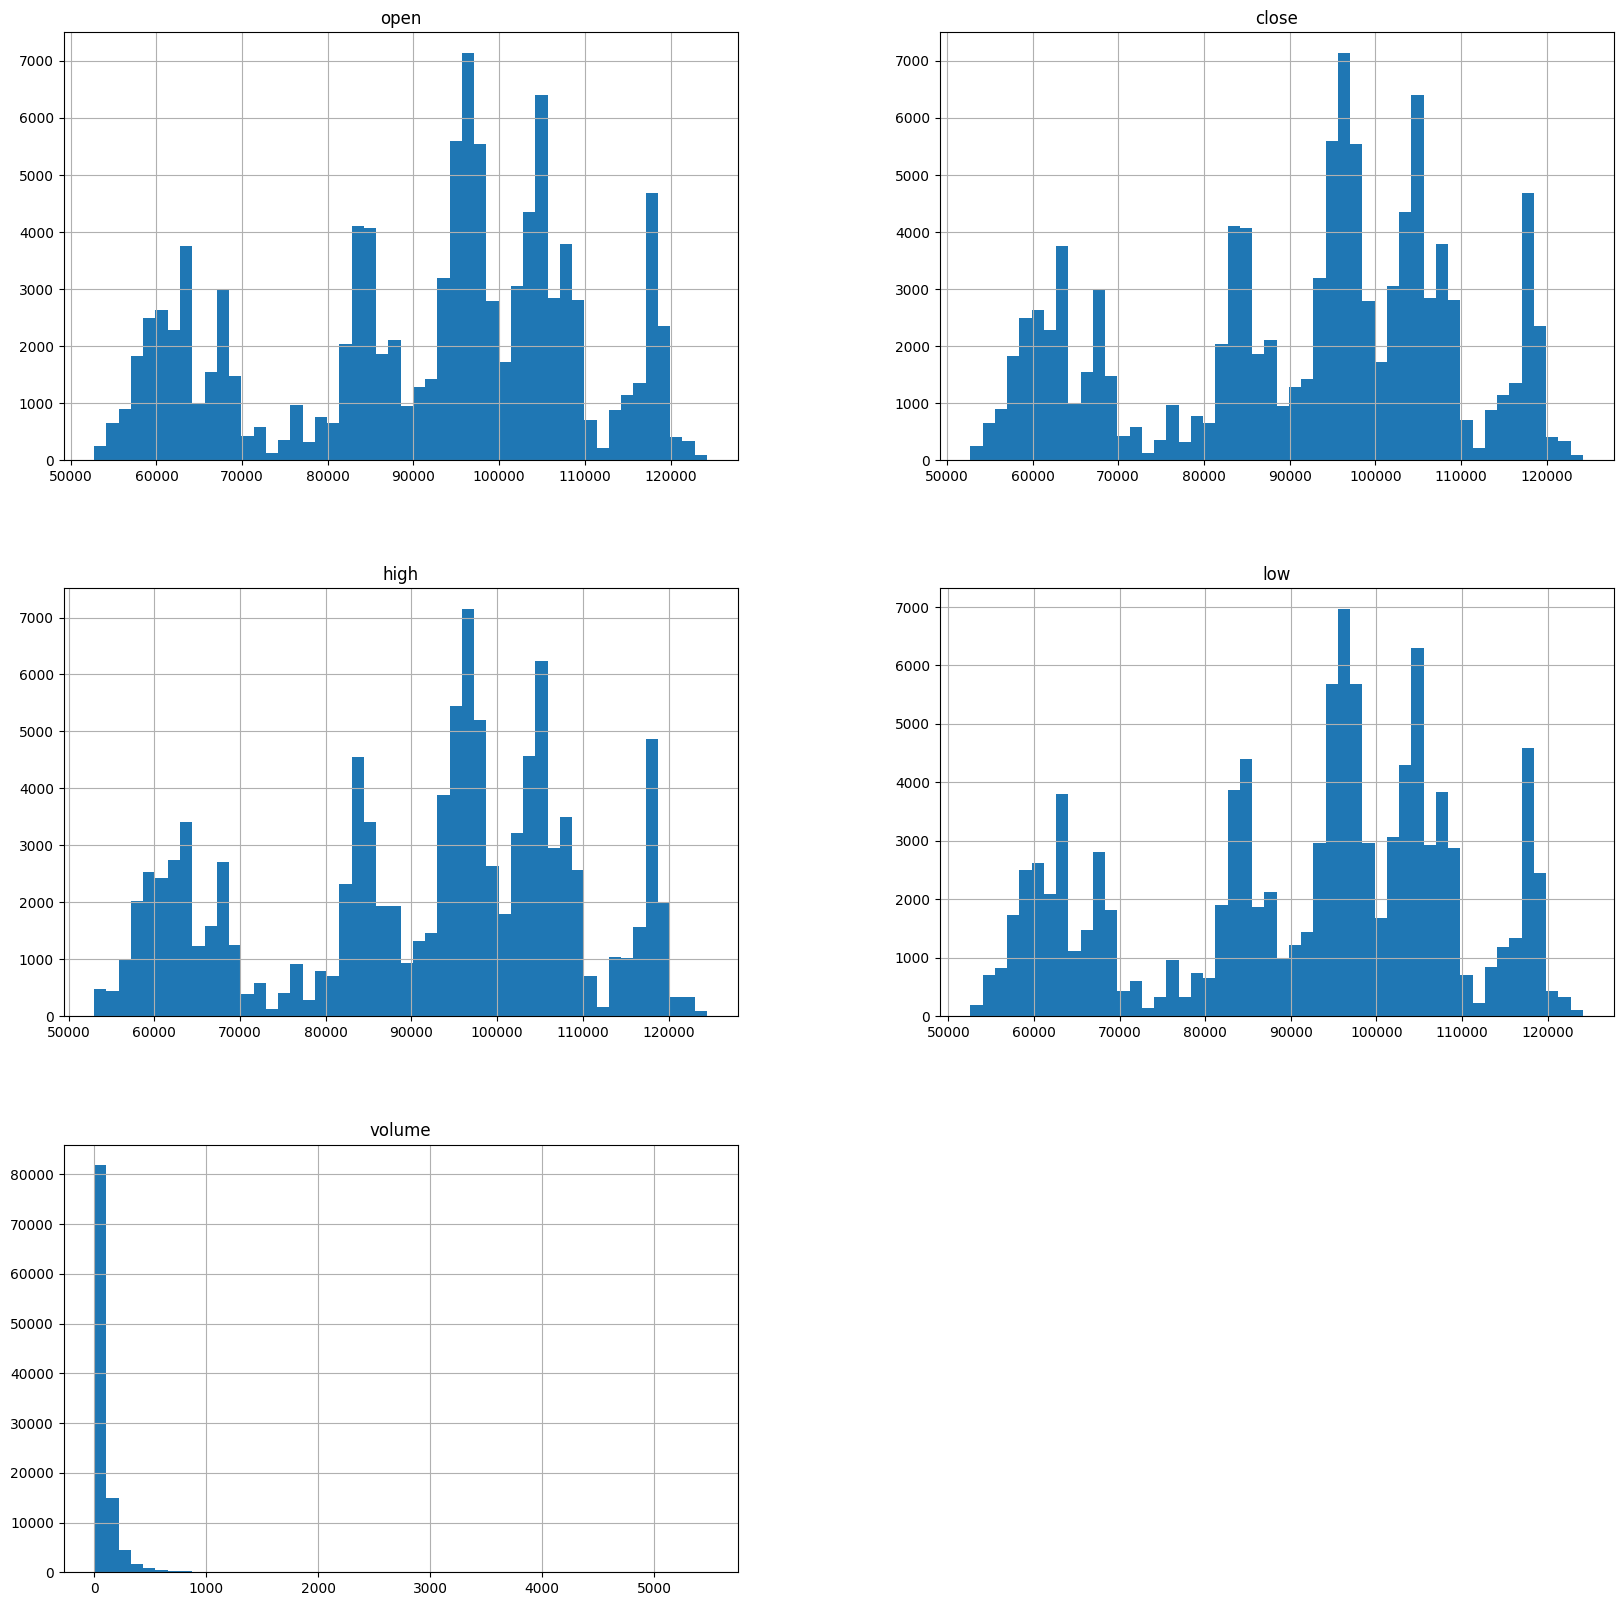

In [44]:
df[OCHLV].hist(figsize=(20, 20), bins=50)
plt.show()

##### <font> I can say that Open, Close, High and Low share the same pattern. The exception is Volume. </font>

#### <font color="yellow"> MOMENTUM. </font>

In [45]:
df[MOMENTUM].describe()

,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI
count,105088.000000,105112.000000,105096.000000,105088.000000,105088.000000,105096.000000,105088.000000,105088.000000,105109.000000,105108.000000,105095.000000,105108.000000,105106.000000,105084.000000
mean,8.020550,91270.982116,0.004361,0.000001,0.004364,-2.653120,0.000751,-2.652591,0.009068,50.479165,0.500762,51.251076,51.251572,0.977225
std,365.473685,17904.434051,0.160280,0.048126,0.150985,16.368742,8.115053,13.624496,0.493862,11.071863,0.356985,30.199768,27.978910,18.642137
min,-3567.873088,53352.968576,-1.366970,-0.561299,-1.103215,-58.109294,-21.727011,-54.221191,-5.478025,8.474526,0.000000,0.000000,0.000000,-70.563083
25%,-144.169279,81769.833780,-0.062126,-0.021532,-0.058666,-14.072403,-5.307956,-12.142807,-0.201789,42.987138,0.165016,24.693090,25.853164,-11.934502
50%,11.054647,95657.374058,0.005665,-0.000537,0.005410,-4.533470,-1.054626,-3.579108,0.006764,50.636606,0.500690,51.767159,51.739948,1.167823
75%,166.152743,104633.854863,0.074533,0.021367,0.070735,6.758948,3.934897,5.829387,0.221666,57.985763,0.838742,78.064900,76.824310,13.734335
max,4895.497941,123679.668836,1.823188,0.601623,1.701378,84.770303,79.463573,50.542363,6.317099,94.850855,1.000000,100.000000,100.000000,82.250890


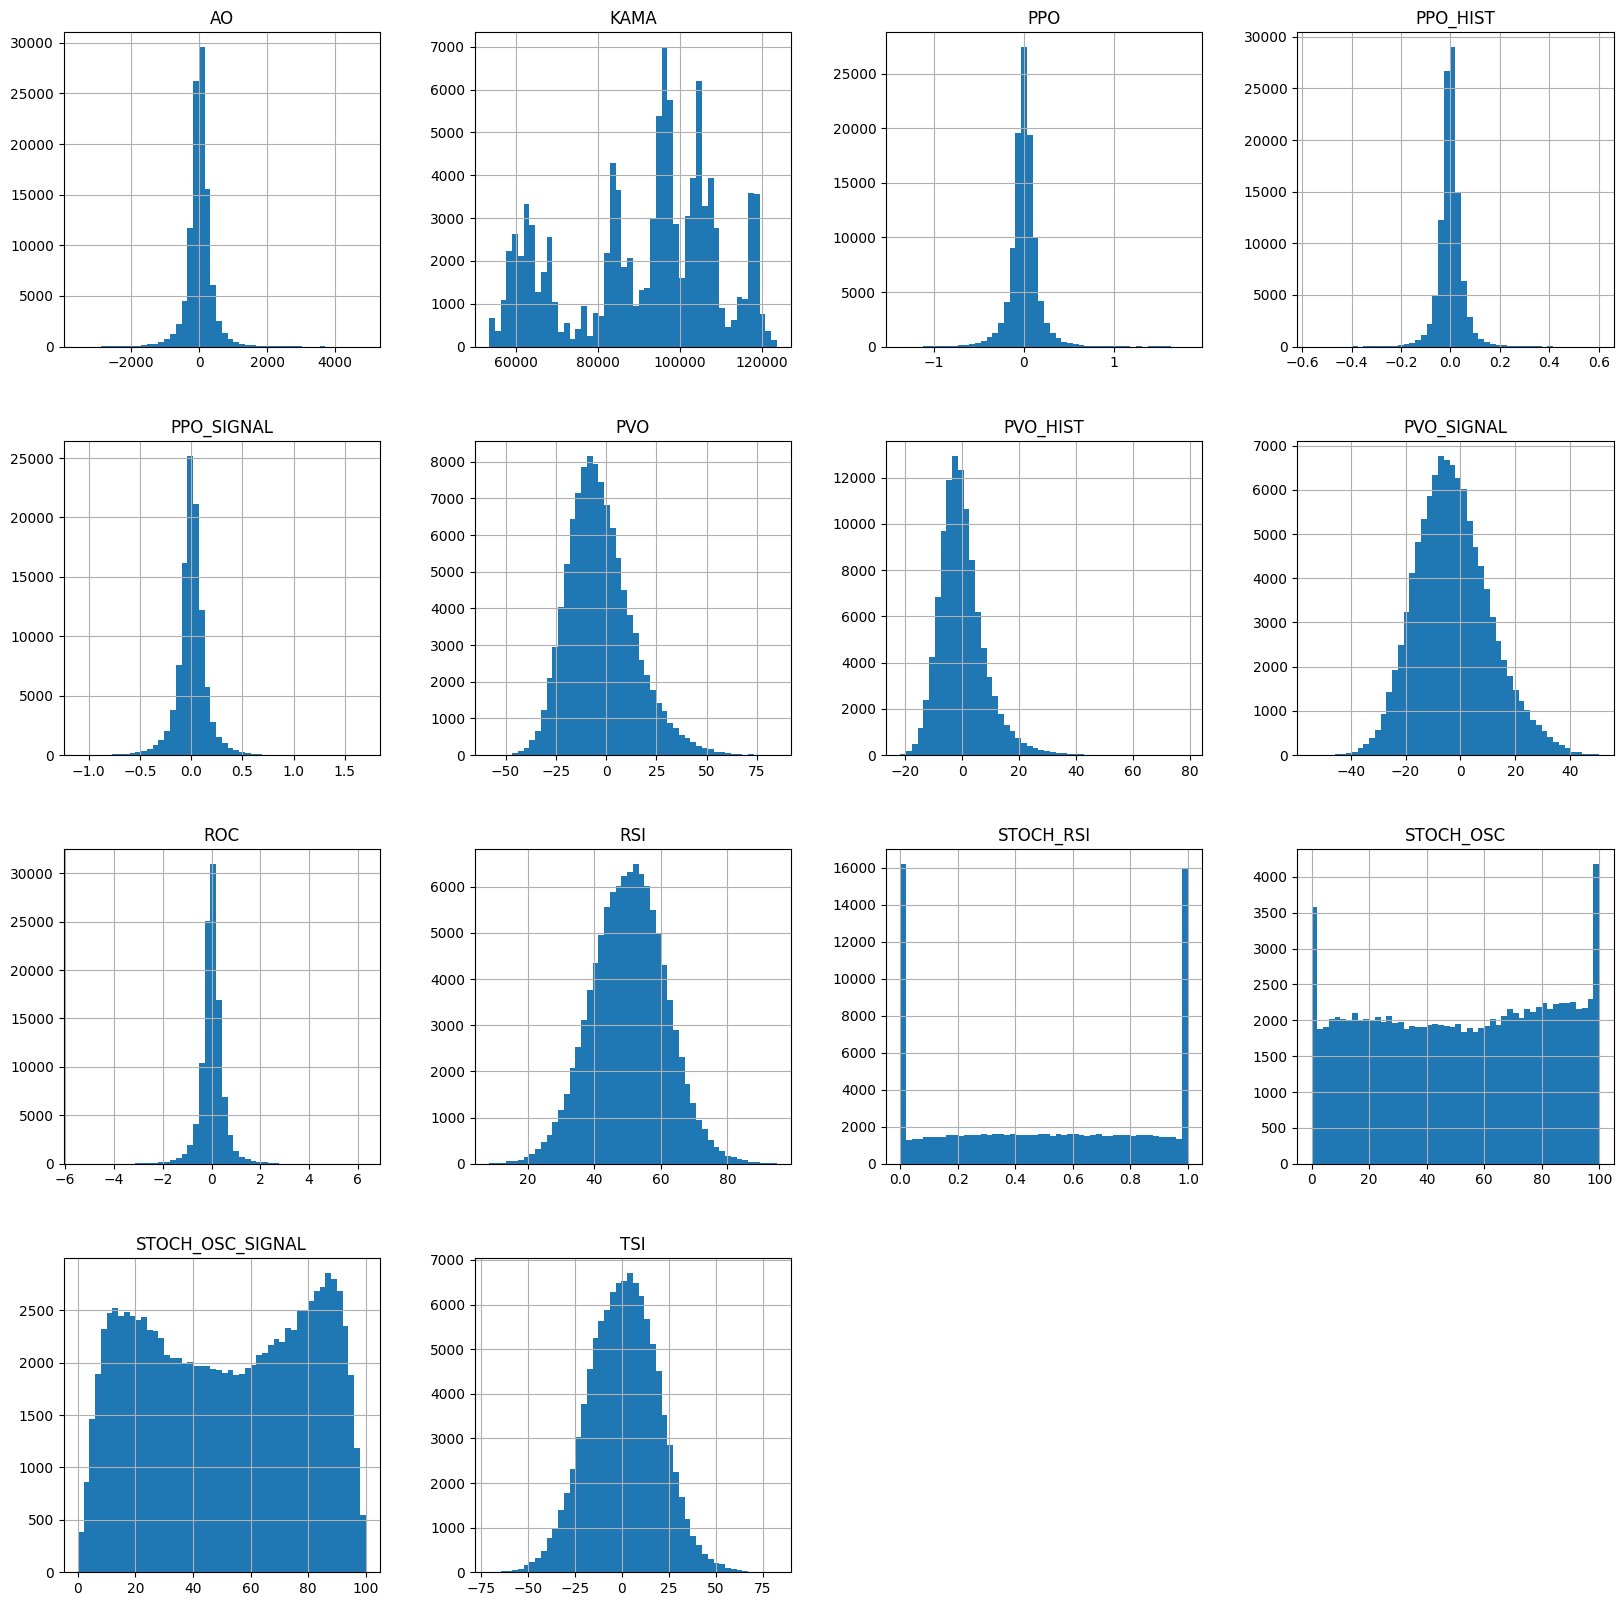

In [46]:
df[MOMENTUM].hist(figsize=(20, 20), bins=50)
plt.show()

##### <font color="yellow"> MOMENTUM. </font>
<font color="#5283fe">BELL</font>
<ol>
  <li>AO</li>
  <li>PPO</li>
  <li>PPO Hist</li>
  <li>PPO Signal</li>
  <li>PVO</li>
  <li>PVO Hist</li>
  <li>PVO Signal</li>
  <li>ROC</li>
  <li>RSI</li>
  <li>TSI</li>
</ol>
<p>Is the same pattern for these indicators, so there are posibilities that we can discard some of this indicators.</p>

<font color="#5283fe">Same as Open, Close, High and Low</font>
<ol>
  <li>KAMA</li>
</ol>
<p>This indicator has the same pattern as OHCL, so there are possibilities that they are correlated.</p>

<font color="#5283fe">Other</font>
<ol>
  <li>STOCH RSI</li>
  <li>STOCH OSC</li>
  <li>STOCH OSC SIGNAL</li>
</ol>
<p>Need to understand how this works.</p>

#### <font color="yellow"> Volumen </font>

In [47]:
df[VOLUME].describe()

,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT,VWAP
count,105121.000000,105102.000000,1.051200e+05,1.051070e+05,1.051080e+05,105108.000000,105121.000000,105121.000000,105120.000000,105108.000000
mean,120760.006750,0.012819,1.815108e+08,1.829709e+08,1.596592e+02,50.135091,2123.228054,56754.495146,42.536349,91269.131136
std,56181.097726,0.172965,2.480629e+10,6.715702e+09,2.961128e+04,18.056989,682.391688,27339.192492,111.238996,17901.046907
min,-1124.944735,-0.756104,-5.326924e+11,-5.958277e+10,-3.136686e+06,0.000000,963.931640,-6563.076440,-172.036255,53061.201721
25%,100849.847924,-0.104120,-9.531326e+09,-3.004539e+09,-1.050186e+03,36.816993,1454.064285,40879.619337,-89.561340,81784.794470
50%,149225.345938,0.010125,6.791810e+06,1.478330e+08,3.009422e+01,50.037060,2173.402568,60961.235222,84.088255,95635.337241
75%,157548.360439,0.129082,9.647536e+09,3.380693e+09,1.209681e+03,63.537983,2703.358710,80225.720582,126.084889,104635.746251
max,172427.839752,0.805719,3.661549e+11,6.058626e+10,1.250264e+06,100.000000,3545.473794,109296.728275,280.706313,123891.893286


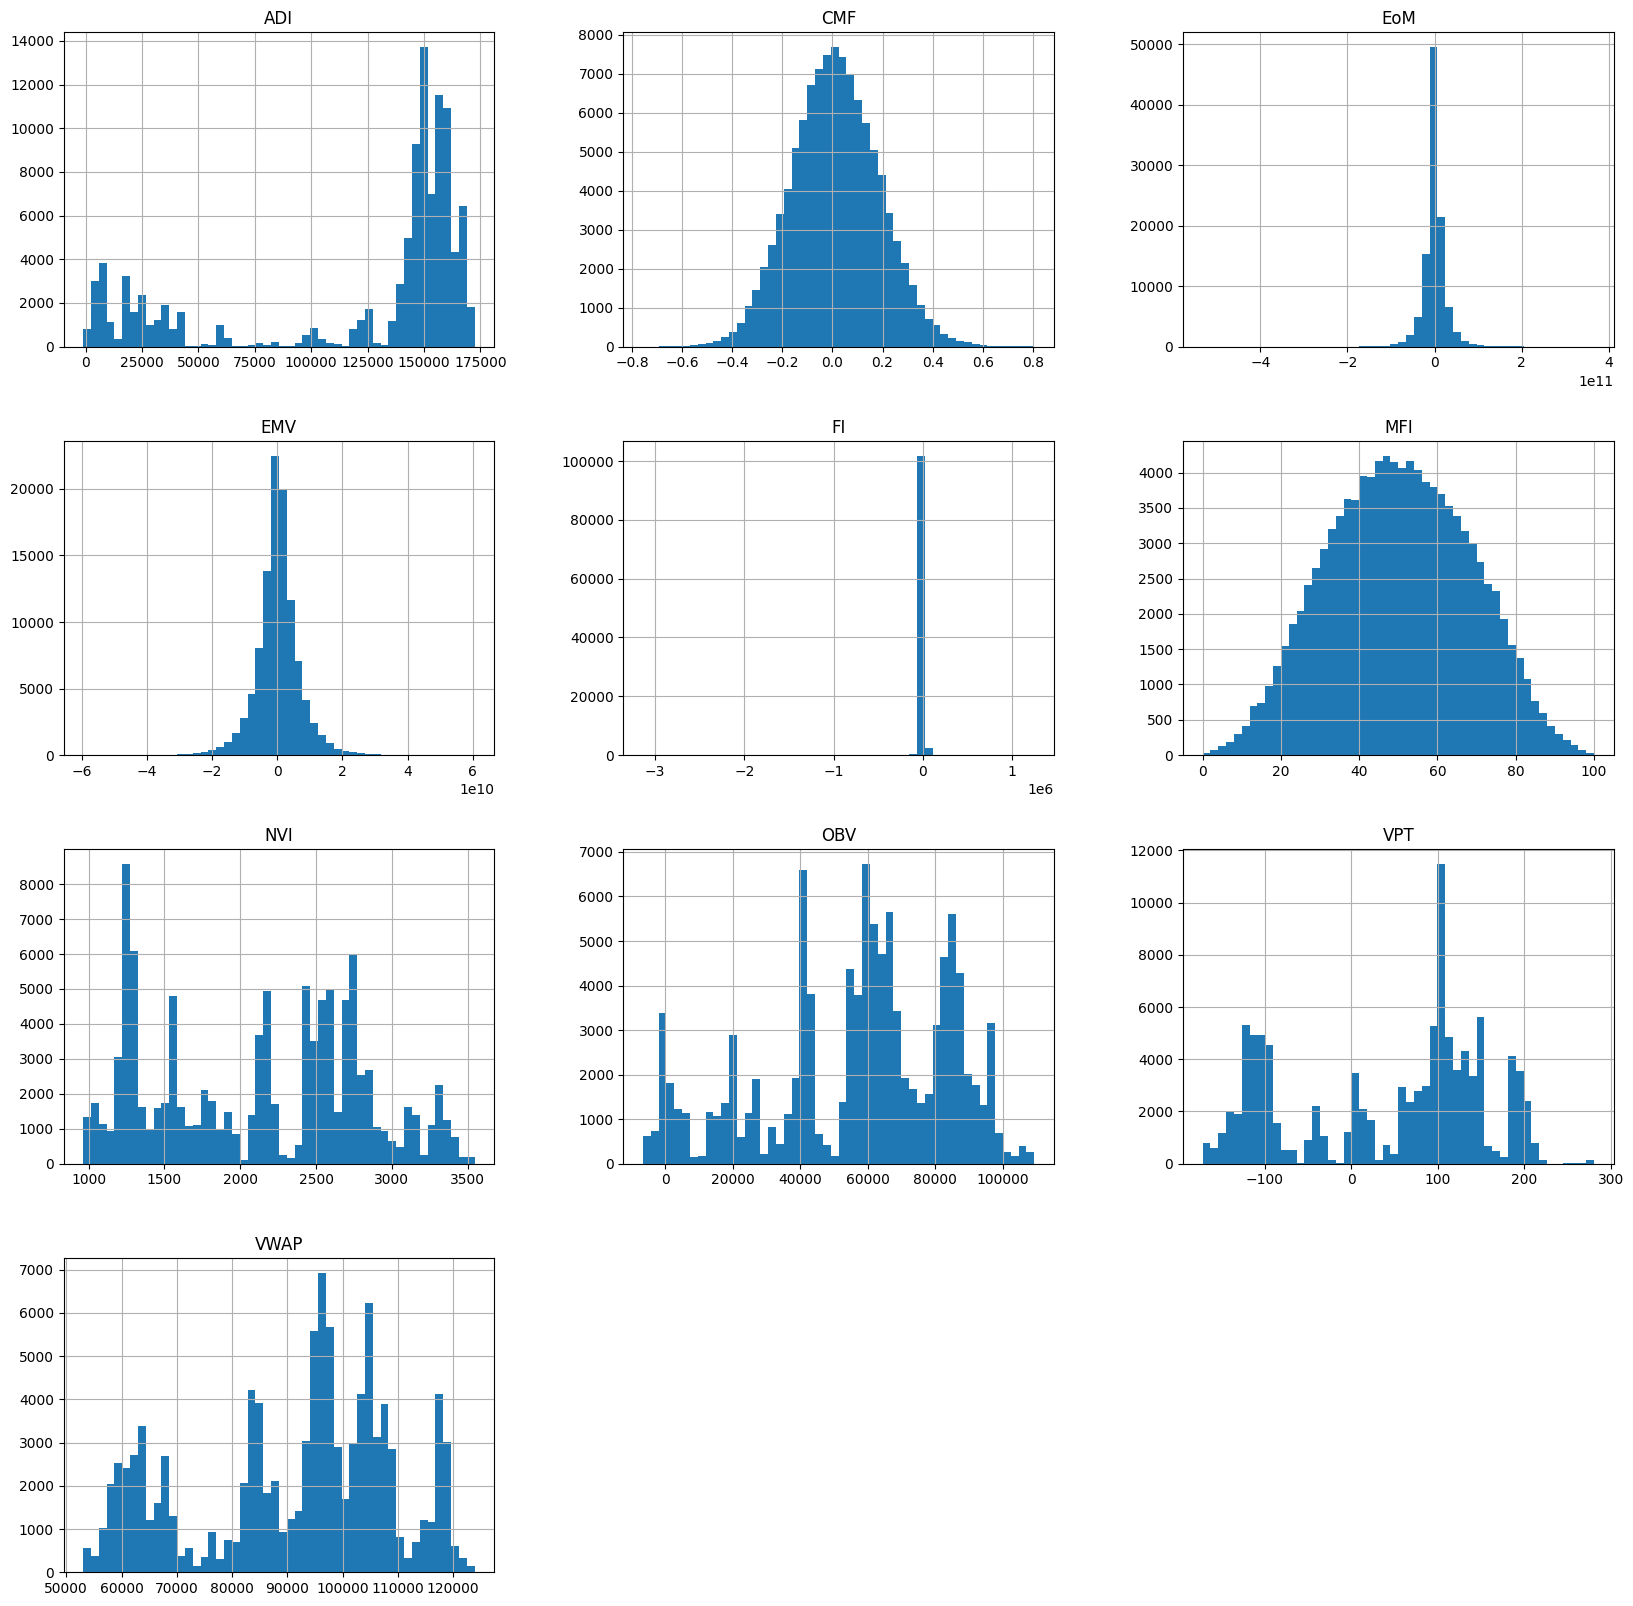

In [48]:
df[VOLUME].hist(figsize=(20, 20), bins=50)
plt.show()

##### <font color="yellow"> VOLUME </font>
<font color="#5283fe">BELL</font>
<ol>
  <li>CMF</li>
  <li>MFI</li>
  <li>EoM</li>
  <li>EMV</li>
  <li>FI</li>
</ol>
<p>Is the same pattern for these indicators, need the check the scale.</p>

<font color="#5283fe">Same as Open, Close, High and Low</font>
<ol>
  <li>VWAP</li>
</ol>
<p>This indicator has the same pattern as OHCL, so there are possibilities that they are correlated.</p>

<font color="#5283fe">Unique Patterns</font>
<ol>
  <li>ADI</li>
  <li>NVI</li>
  <li>OBV</li>
  <li>VPT</li>
</ol>
<p>Need to understand how this works.</p>

####  <font color="yellow">VOLATILITY </font>

In [49]:
df[VOLATILITY].describe()

,ATR,BBANDS_HIGH,BBANDS_HIGH_INDI,BBANDS_LOWER,BBANDS_LOWER_INDI,BBANDS_MIDDLE,BBANDS_CHANNEL,BBANDS_WIDTH,DONCHIAN_HIGH,DONCHIAN_LOW,...,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH,KELTNER_HIGH,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX
count,105121.000000,105102.000000,105121.000000,105102.000000,105121.000000,105102.000000,105102.000000,105102.000000,105102.000000,105102.000000,...,105102.000000,105102.000000,105121.000000,105121.000000,105121.000000,105121.000000,105102.000000,105121.000000,105102.000000,105108.000000
mean,154.115318,91631.479083,0.056554,90914.352925,0.057496,91272.916004,0.506558,0.798135,91649.702627,90876.425859,...,0.515517,0.862031,91420.356415,0.287269,91112.082257,0.268053,91272.118523,0.527351,0.343838,0.317270
std,99.646804,17938.849136,0.230989,17865.495647,0.232788,17899.607845,0.328909,0.674385,17936.092498,17863.503985,...,0.296934,0.659353,17917.093529,0.452490,17889.937751,0.442947,17899.453465,0.880357,0.231760,0.306238
min,0.000000,53840.849612,0.000000,52780.749972,0.000000,53328.063500,-0.567205,0.045125,53766.580000,52550.000000,...,0.000000,0.062432,53571.279000,0.000000,53060.595833,0.000000,53316.706833,-4.195300,0.012817,0.000000
25%,87.372454,82224.147201,0.000000,81304.724107,0.000000,81791.997250,0.241046,0.397854,82270.510000,81278.520000,...,0.255670,0.456410,81986.917333,0.000000,81567.803500,0.000000,81792.508958,-0.046944,0.193806,0.132858
50%,129.521767,96030.550009,0.000000,95237.167639,0.000000,95659.808250,0.516492,0.603332,96052.000000,95221.350000,...,0.525509,0.680393,95822.369500,0.000000,95475.637500,0.000000,95660.285333,0.535510,0.284063,0.229593
75%,191.828377,104975.462143,0.000000,104267.580934,0.000000,104638.041000,0.768680,0.953446,104989.452500,104215.742500,...,0.776000,1.043572,104783.170667,1.000000,104485.188500,1.000000,104636.561792,1.092709,0.422778,0.388563
max,1476.575039,124257.812532,1.000000,123396.420965,1.000000,123767.372000,1.566416,10.448934,124474.000000,123387.520000,...,1.000000,9.153261,124022.087667,1.000000,123506.969167,1.000000,123762.460167,5.887386,2.983277,4.323758


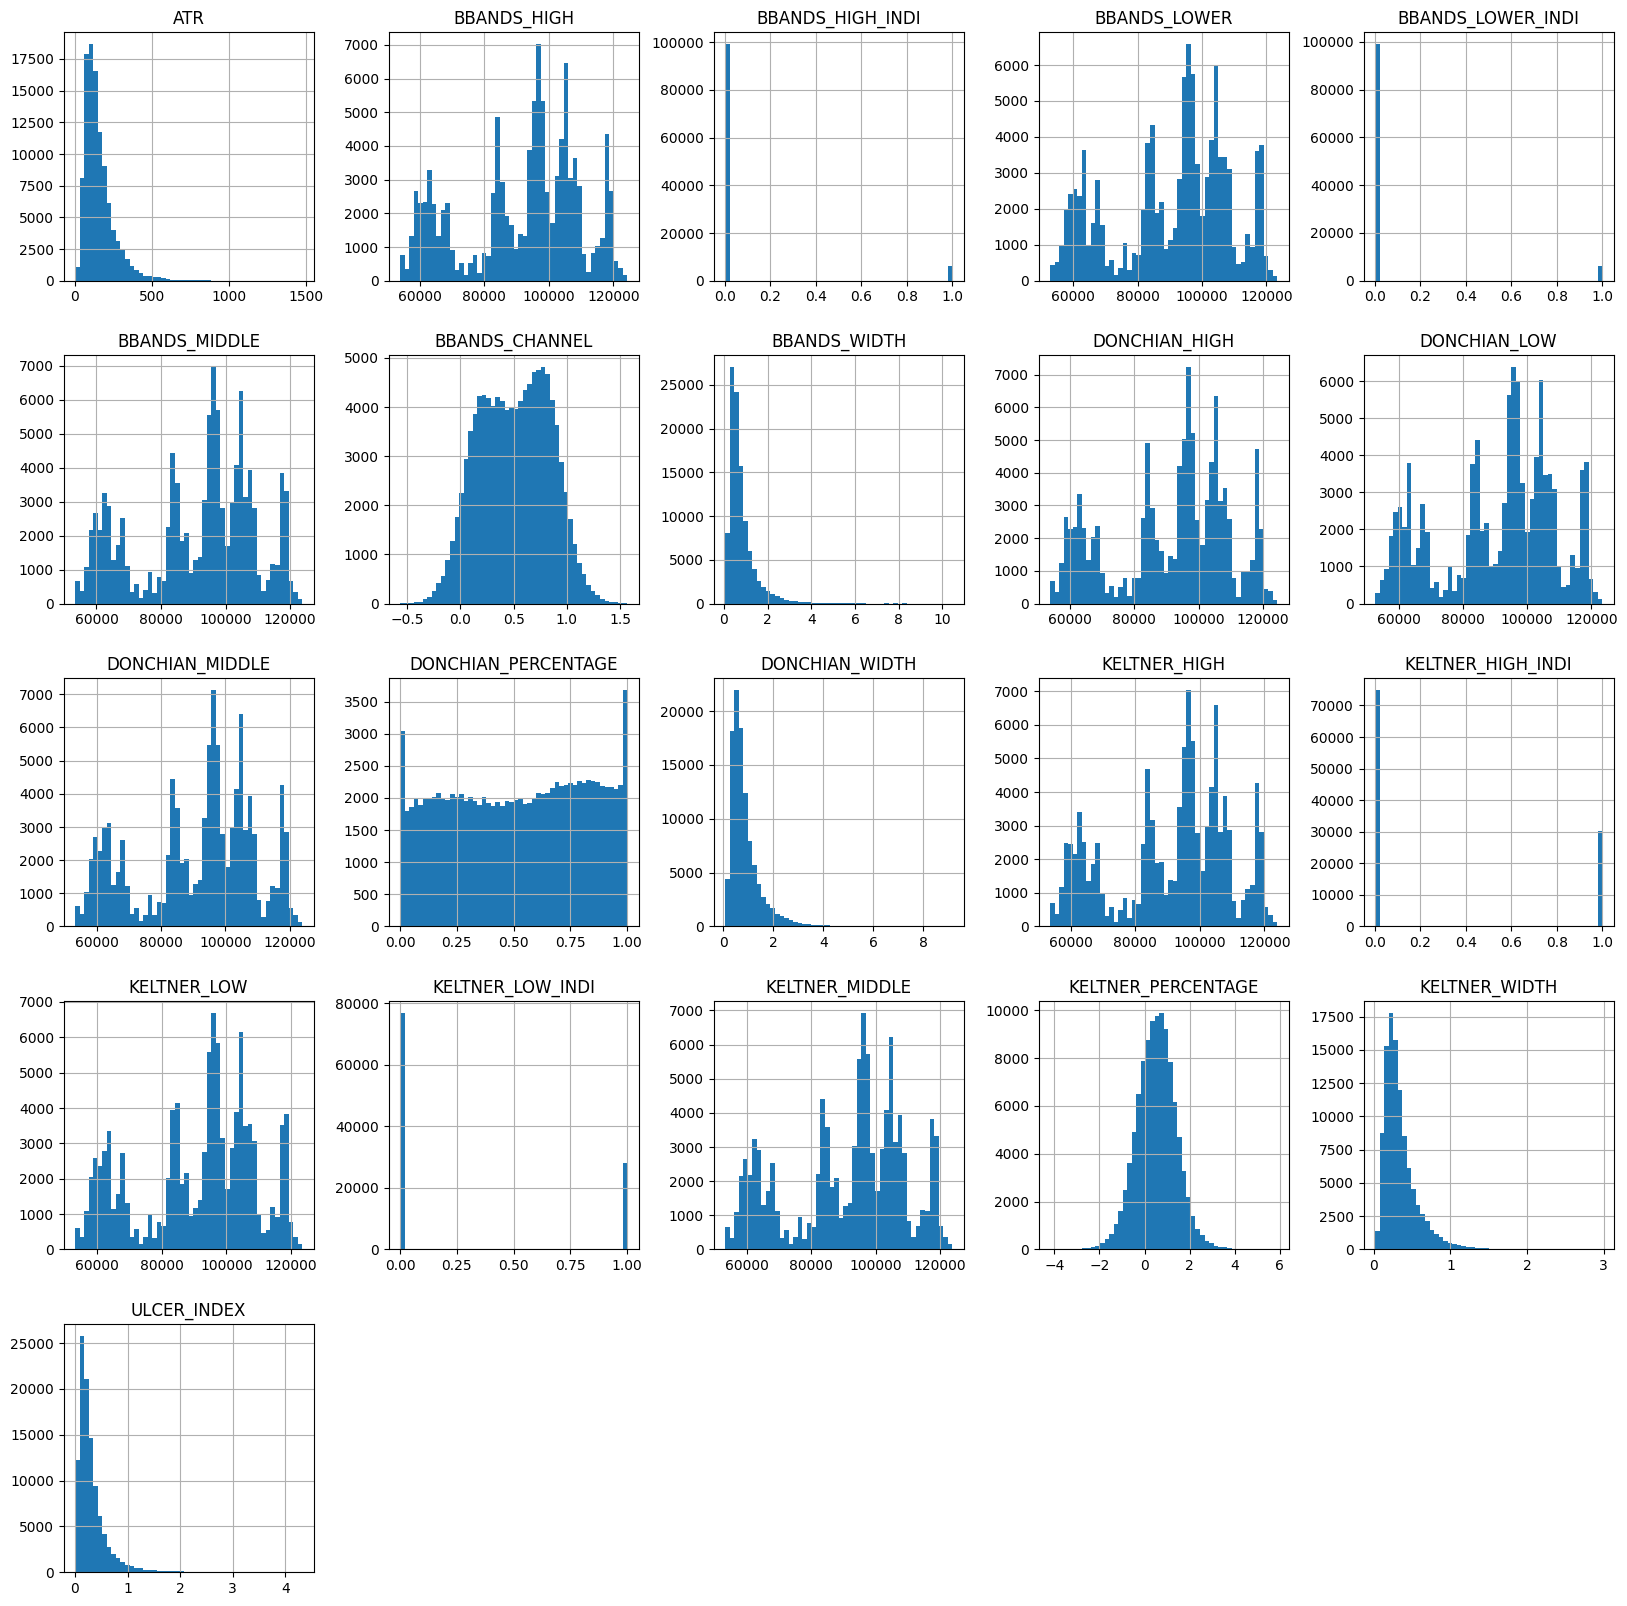

In [50]:
df[VOLATILITY].hist(figsize=(20, 20), bins=50)
plt.show()

##### <font color="yellow">VOLATILITY </font>

<font color="#5283fe">Same as Open, Close, High and Low</font>
<ol>
  <li>BBANDS HIGH</li>
  <li>BBANDS LOWER</li>
  <li>BBANDS MIDDLE</li>
  <li>KELTNER HIGH</li>
  <li>KELTNER LOWER</li>
  <li>KELTNER MIDDLE</li>
  <li>DONCHIAN HIGH</li>
  <li>DONCHIAN LOWER</li>
  <li>DONCHIAN MIDDLE</li>
</ol>
<p>This indicator has the same pattern as OHCL, so there are possibilities that they are correlated. Also if they have the same porpouse probably im gonna need to chose one between Bolinger Bands, Keltner or Donchian.</p>

<font color="#5283fe">Indicators (0 or 1)</font>
<ol>
  <li>BBANDS HIGH INDI</li>
  <li>BBANDS LOWER INDI</li>
  <li>DONCHIAN HIGH INDI</li>
  <li>DONCHIAN LOWER INDI</li>
</ol>
<p>The same as before, need to choose one.</p>

<font color="#5283fe">Width</font>
<ol>
  <li>BBANDS Width</li>
  <li>DONCHIAN Width</li>
  <li>KELTNER Width</li>
  <li>ULCER INDEX</li>
  <li>ATR</li>
</ol>
<p>Need to understand how this works.</p>

#### <font color="yellow">TREND </font>

In [51]:
df[TREND].describe()

,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO,EMA,KST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
count,105121.000000,105121.000000,105121.000000,105096.000000,105096.000000,105096.000000,105102.000000,105102.000000,105108.000000,105107.000000,...,105107.000000,105096.000000,105088.000000,105088.000000,105081.000000,105108.000000,105107.000000,105107.000000,105107.000000,105108.000000
mean,24.276241,23.794374,23.695570,48.086549,46.614067,1.472482,2.201780,-0.820627,91272.705986,0.119943,...,0.012507,3.861284,3.864140,0.000012,24.928839,91272.705881,1.007170,0.994479,0.012691,91273.899889
std,9.928112,8.244137,7.921187,35.594004,35.677266,61.849724,110.898829,174.900524,17900.387757,6.311472,...,1.867942,144.338039,135.957144,43.364489,1.617450,17900.922122,0.177762,0.175099,0.348208,17900.856642
min,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,-641.543838,-3034.398000,53238.477141,-340.960747,...,-18.246464,-1204.342743,-956.947865,-495.832950,18.347100,53209.755714,0.206660,0.139208,-1.406880,53165.028000
25%,16.844188,18.041660,18.109641,12.000000,12.000000,-56.000000,-84.113003,-76.683875,81791.453364,-2.123169,...,-0.781091,-55.720628,-52.167809,-19.086386,23.814282,81781.213393,0.881270,0.873225,-0.237852,81776.572762
50%,22.160290,23.159319,23.101106,48.000000,44.000000,12.000000,5.892070,0.240250,95654.950544,0.173463,...,-0.019114,4.965132,4.726006,-0.444737,24.747578,95660.287143,1.010383,0.999056,0.011294,95658.485429
75%,29.758418,28.764521,28.574438,84.000000,80.000000,56.000000,86.967897,76.868000,104638.347498,2.543810,...,0.772058,66.872037,63.598237,19.151117,25.857852,104635.825357,1.133983,1.120715,0.259211,104638.298310
max,73.064511,77.389260,75.661542,100.000000,100.000000,100.000000,604.051272,2156.694500,123750.796970,64.420254,...,66.703883,1713.440432,1543.369576,632.062555,32.771013,123831.152143,1.964244,1.821787,1.643643,123844.266190


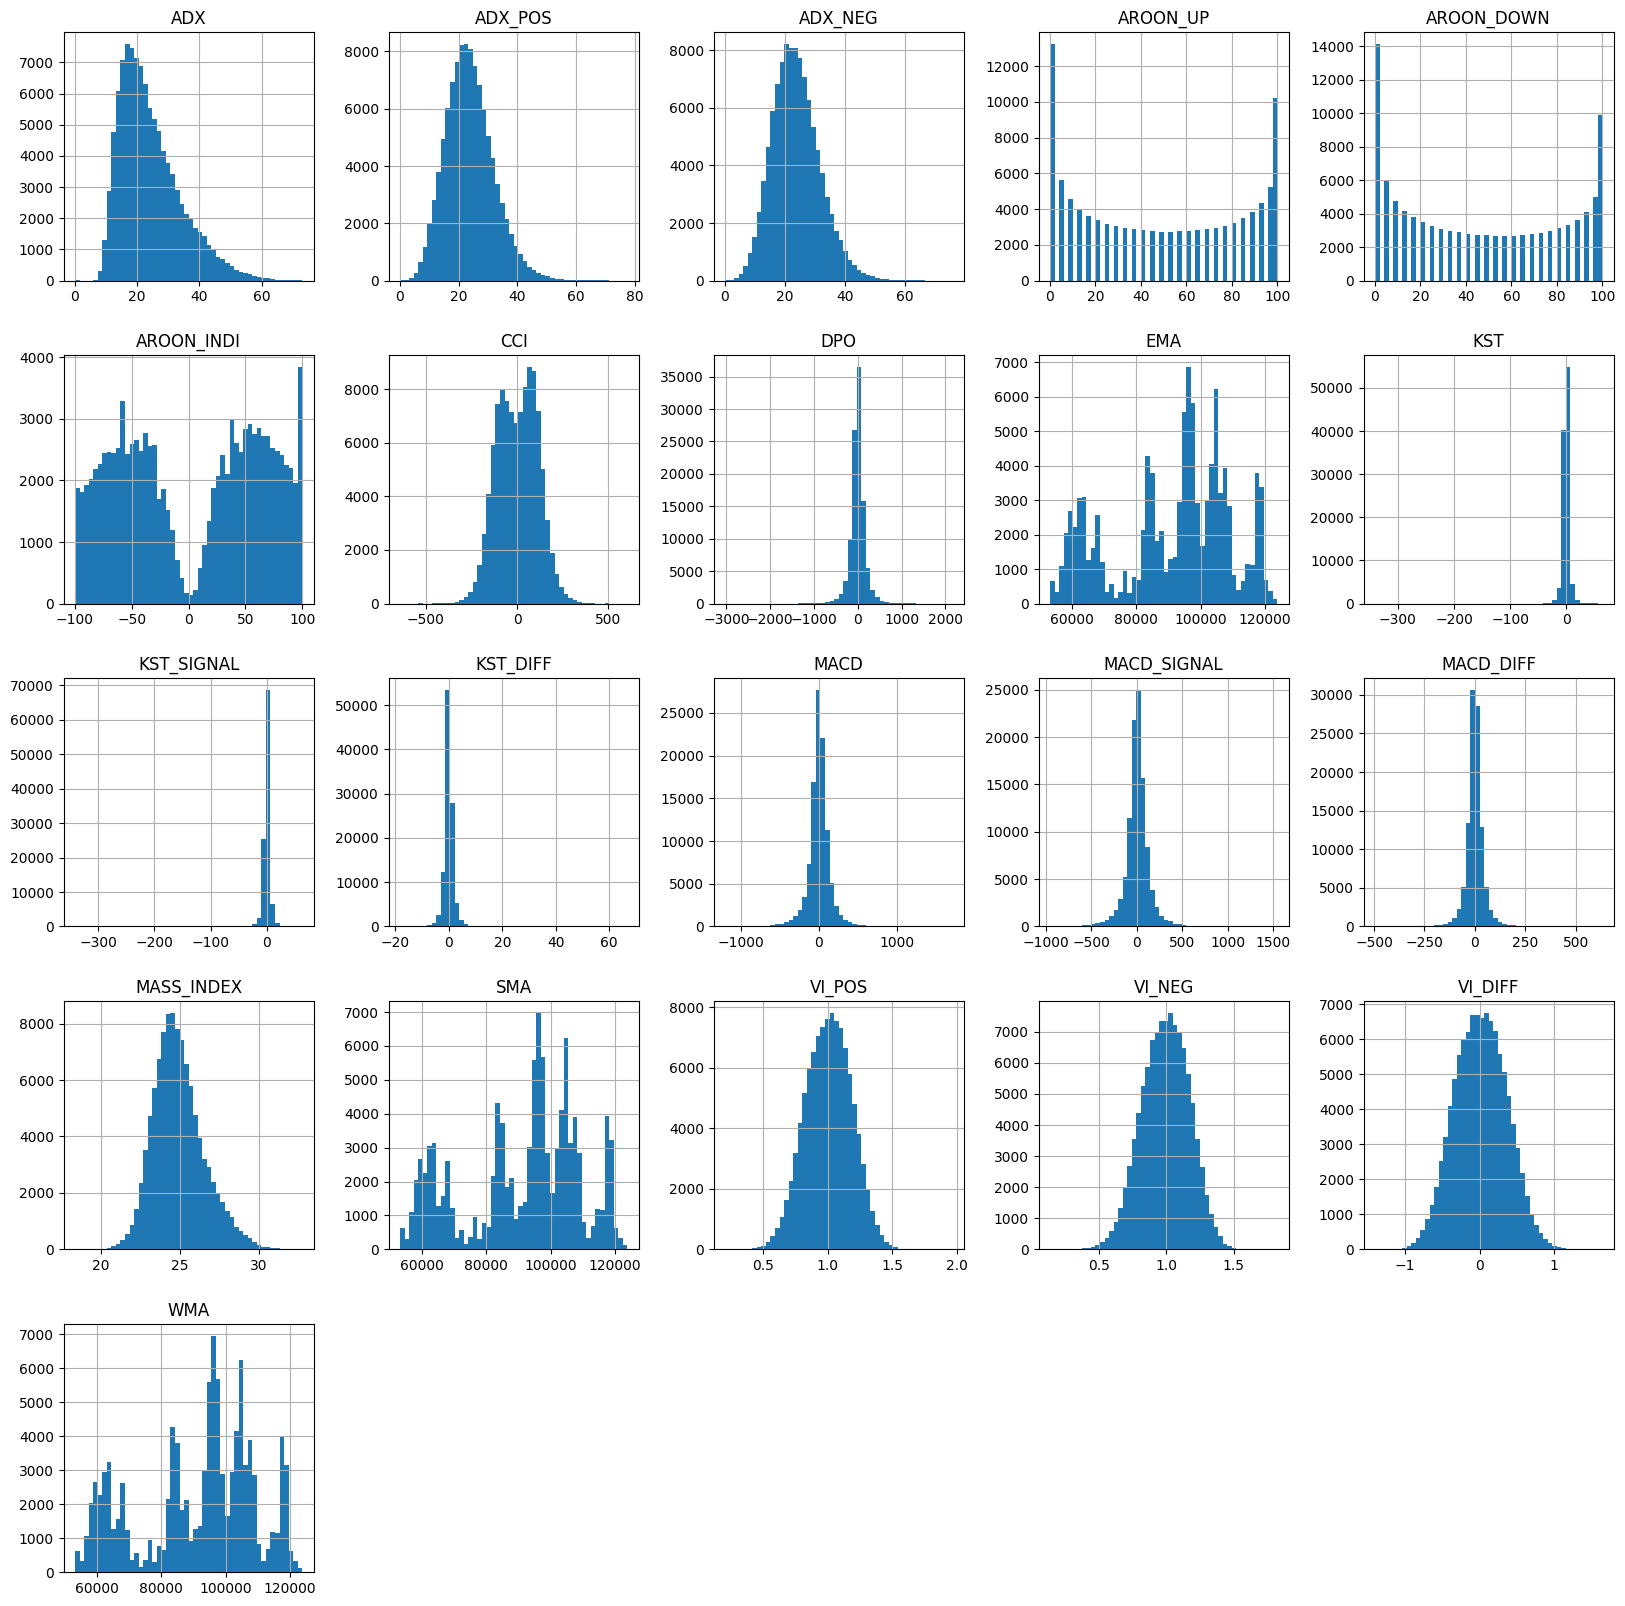

In [52]:
df[TREND].hist(figsize=(20, 20), bins=50)
plt.show()

##### <font color="yellow">TREND </font>

<font color="#5283fe">Same as Open, Close, High and Low</font>
<ol>
  <li>VMA</li>
  <li>SMA</li>
  <li>EMA</li>
</ol>
<p>This indicator has the same pattern as OHCL, so there are possibilities that they are correlated. Also if they have the same porpouse probably im gonna need to chose one and discard the others.</p>

<font color="#5283fe">BELL</font>
<ol>
  <li>ADX</li>
  <li>CCI</li>
  <li>DPO</li>
  <li>KST</li>
  <li>MACD</li>
  <li>MASS</li>
  <li>VI</li>
</ol>
<p>The same as before, need to choose one.</p>

<font color="#5283fe">Aroon</font>
<ol>
  <li>AROON UP</li>
  <li>AROON DOWN</li>
  <li>AROON INDICATOR</li>
</ol>
<p>Need to understand how this works.</p>

# Explore Data

In [53]:
velas = df.copy()

### Look for correlations

##### OCHLV

In [54]:
velas[OCHLV].corr()

,open,close,high,low,volume
open,1.000000,0.999973,0.999984,0.999983,-0.078092
close,0.999973,1.000000,0.999985,0.999984,-0.078044
high,0.999984,0.999985,1.000000,0.999970,-0.075108
low,0.999983,0.999984,0.999970,1.000000,-0.081215
volume,-0.078092,-0.078044,-0.075108,-0.081215,1.000000


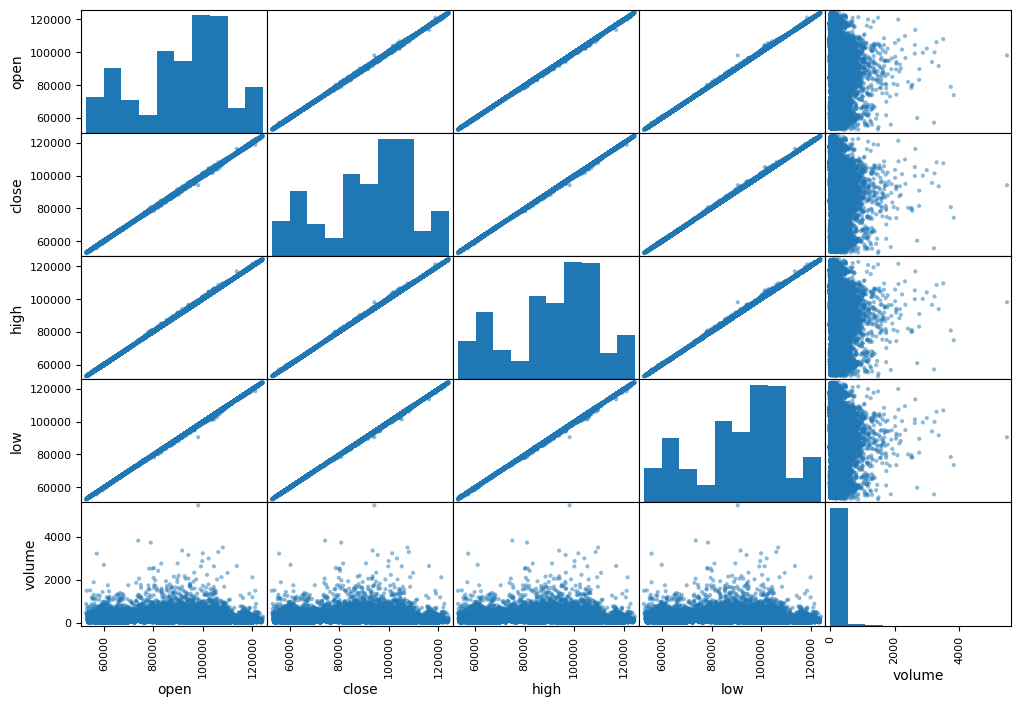

In [55]:
scatter_matrix(velas[OCHLV], figsize=(12, 8))
plt.show()

#### OCHLV with Momentum

In [56]:
VOLUME = ["ADI", "CMF", "EoM", "EMV", "FI", "MFI", "NVI", "OBV", "VPT", "VWAP"]
VOLATILITY = ["ATR", "BBANDS_HIGH", "BBANDS_HIGH_INDI", "BBANDS_LOWER", "BBANDS_LOWER_INDI", "BBANDS_MIDDLE", "BBANDS_CHANNEL", "BBANDS_WIDTH", "DONCHIAN_HIGH", "DONCHIAN_LOW", "DONCHIAN_MIDDLE", "DONCHIAN_PERCENTAGE", "DONCHIAN_WIDTH", "KELTNER_HIGH", "KELTNER_HIGH_INDI", "KELTNER_LOW", "KELTNER_LOW_INDI", "KELTNER_MIDDLE", "KELTNER_PERCENTAGE", "KELTNER_WIDTH", "ULCER_INDEX"]
TREND = ["ADX", "ADX_POS", "ADX_NEG", "AROON_UP", "AROON_DOWN", "AROON_INDI", "CCI", "DPO", "EMA", "KST", "KST_SIGNAL", "KST_DIFF", "MACD", "MACD_SIGNAL", "MACD_DIFF", "MASS_INDEX", "SMA", "VI_POS", "VI_NEG", "VI_DIFF", "WMA"]

In [57]:
MOMENTUM_INDIVIDUALS = ["AO", "KAMA", "ROC", "RSI", "TSI"]
MOMENTUM_PPO = ["PPO", "PPO_HIST", "PPO_SIGNAL"]
MOMENTUM_PVO = ["PVO", "PVO_HIST", "PVO_SIGNAL"]
MOMENTUM_STOCH = ["STOCH_RSI", "STOCH_OSC", "STOCH_OSC_SIGNAL"]

##### Individuals

In [58]:
velas[OCHLV+MOMENTUM_INDIVIDUALS].corr()

,open,close,high,low,volume,AO,KAMA,ROC,RSI,TSI
open,1.000000,0.999973,0.999984,0.999983,-0.078092,0.013168,0.999941,0.003552,0.008982,0.013163
close,0.999973,1.000000,0.999985,0.999984,-0.078044,0.013349,0.999923,0.005586,0.011408,0.013636
high,0.999984,0.999985,1.000000,0.999970,-0.075108,0.012994,0.999933,0.004425,0.010099,0.013230
low,0.999983,0.999984,0.999970,1.000000,-0.081215,0.013678,0.999924,0.004924,0.010530,0.013710
volume,-0.078092,-0.078044,-0.075108,-0.081215,1.000000,-0.027850,-0.077398,-0.017218,-0.008531,-0.009197
AO,0.013168,0.013349,0.012994,0.013678,-0.027850,1.000000,0.006682,0.730978,0.707072,0.834740
KAMA,0.999941,0.999923,0.999933,0.999924,-0.077398,0.006682,1.000000,-0.003413,0.002171,0.007370
ROC,0.003552,0.005586,0.004425,0.004924,-0.017218,0.730978,-0.003413,1.000000,0.746357,0.616869
RSI,0.008982,0.011408,0.010099,0.010530,-0.008531,0.707072,0.002171,0.746357,1.000000,0.855293
TSI,0.013163,0.013636,0.013230,0.013710,-0.009197,0.834740,0.007370,0.616869,0.855293,1.000000


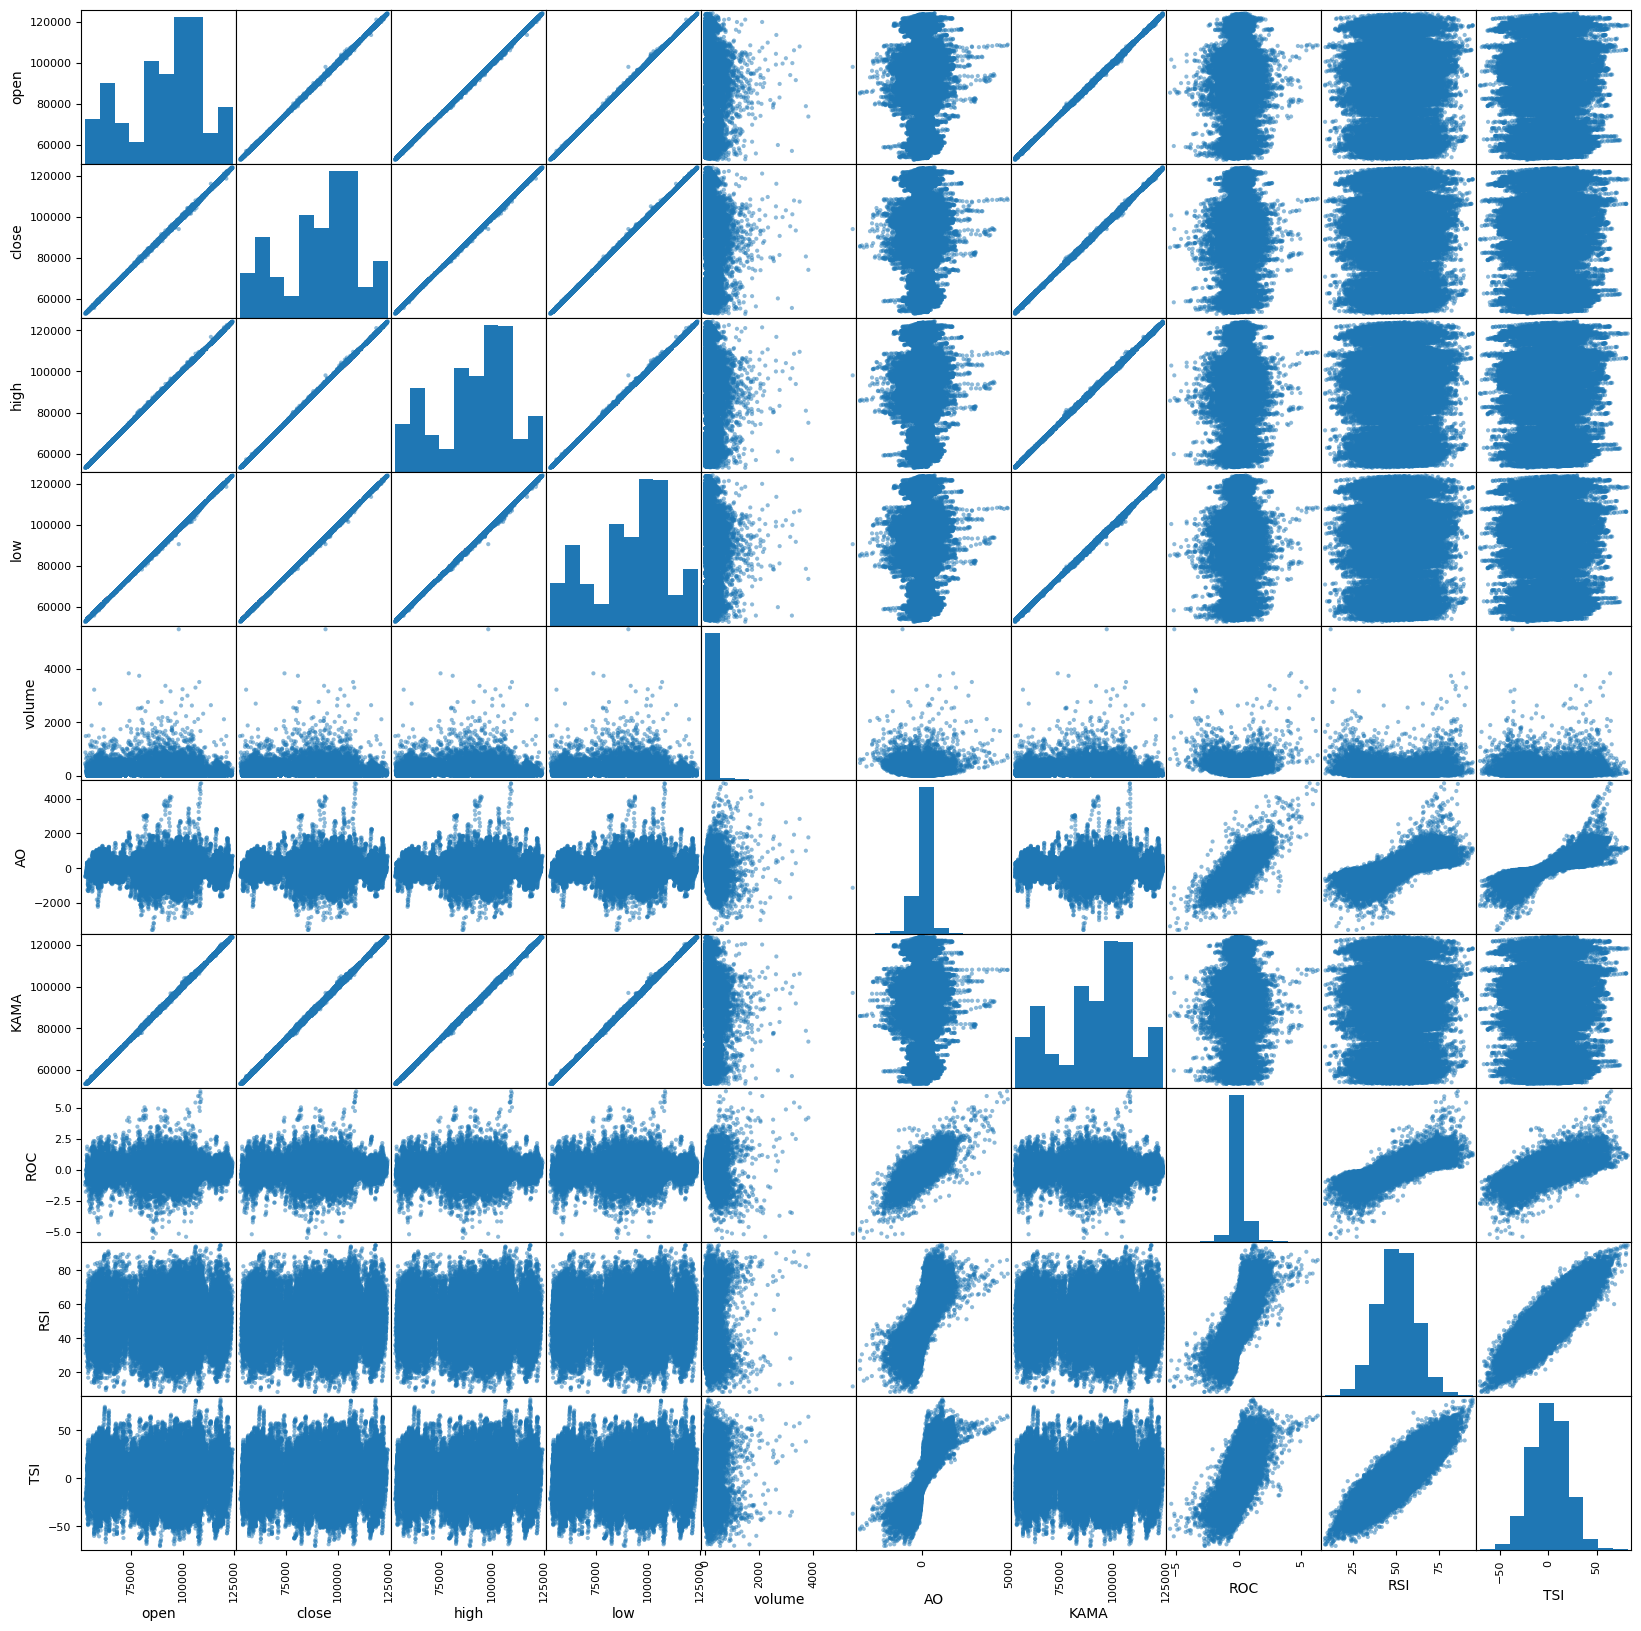

In [59]:
scatter_matrix(velas[OCHLV+MOMENTUM_INDIVIDUALS], figsize=(20, 20))
plt.show()

##### KAMA is related with OCHL, so probably is a good candidate to be in the model as an attribute. AO, TSI, RSI and ROC are correlated, WHY? All four indicators — AO, RSI, TSI, and ROC — are derived from price data, usually close, high, low, or combinations (like median price). That means: They are functions of the same underlying data (OHLCV). Their goal is to measure momentum, just with different math.

##### PPO

In [60]:
velas[OCHLV+MOMENTUM_PPO].corr()

,open,close,high,low,volume,PPO,PPO_HIST,PPO_SIGNAL
open,1.000000,0.999973,0.999984,0.999983,-0.078092,0.010092,-0.001087,0.011005
close,0.999973,1.000000,0.999985,0.999984,-0.078044,0.010560,0.000231,0.011082
high,0.999984,0.999985,1.000000,0.999970,-0.075108,0.010040,-0.000501,0.010762
low,0.999983,0.999984,0.999970,1.000000,-0.081215,0.010738,-0.000215,0.011413
volume,-0.078092,-0.078044,-0.075108,-0.081215,1.000000,-0.022372,-0.021582,-0.016873
PPO,0.010092,0.010560,0.010040,0.010738,-0.022372,1.000000,0.337775,0.953936
PPO_HIST,-0.001087,0.000231,-0.000501,-0.000215,-0.021582,0.337775,1.000000,0.039836
PPO_SIGNAL,0.011005,0.011082,0.010762,0.011413,-0.016873,0.953936,0.039836,1.000000


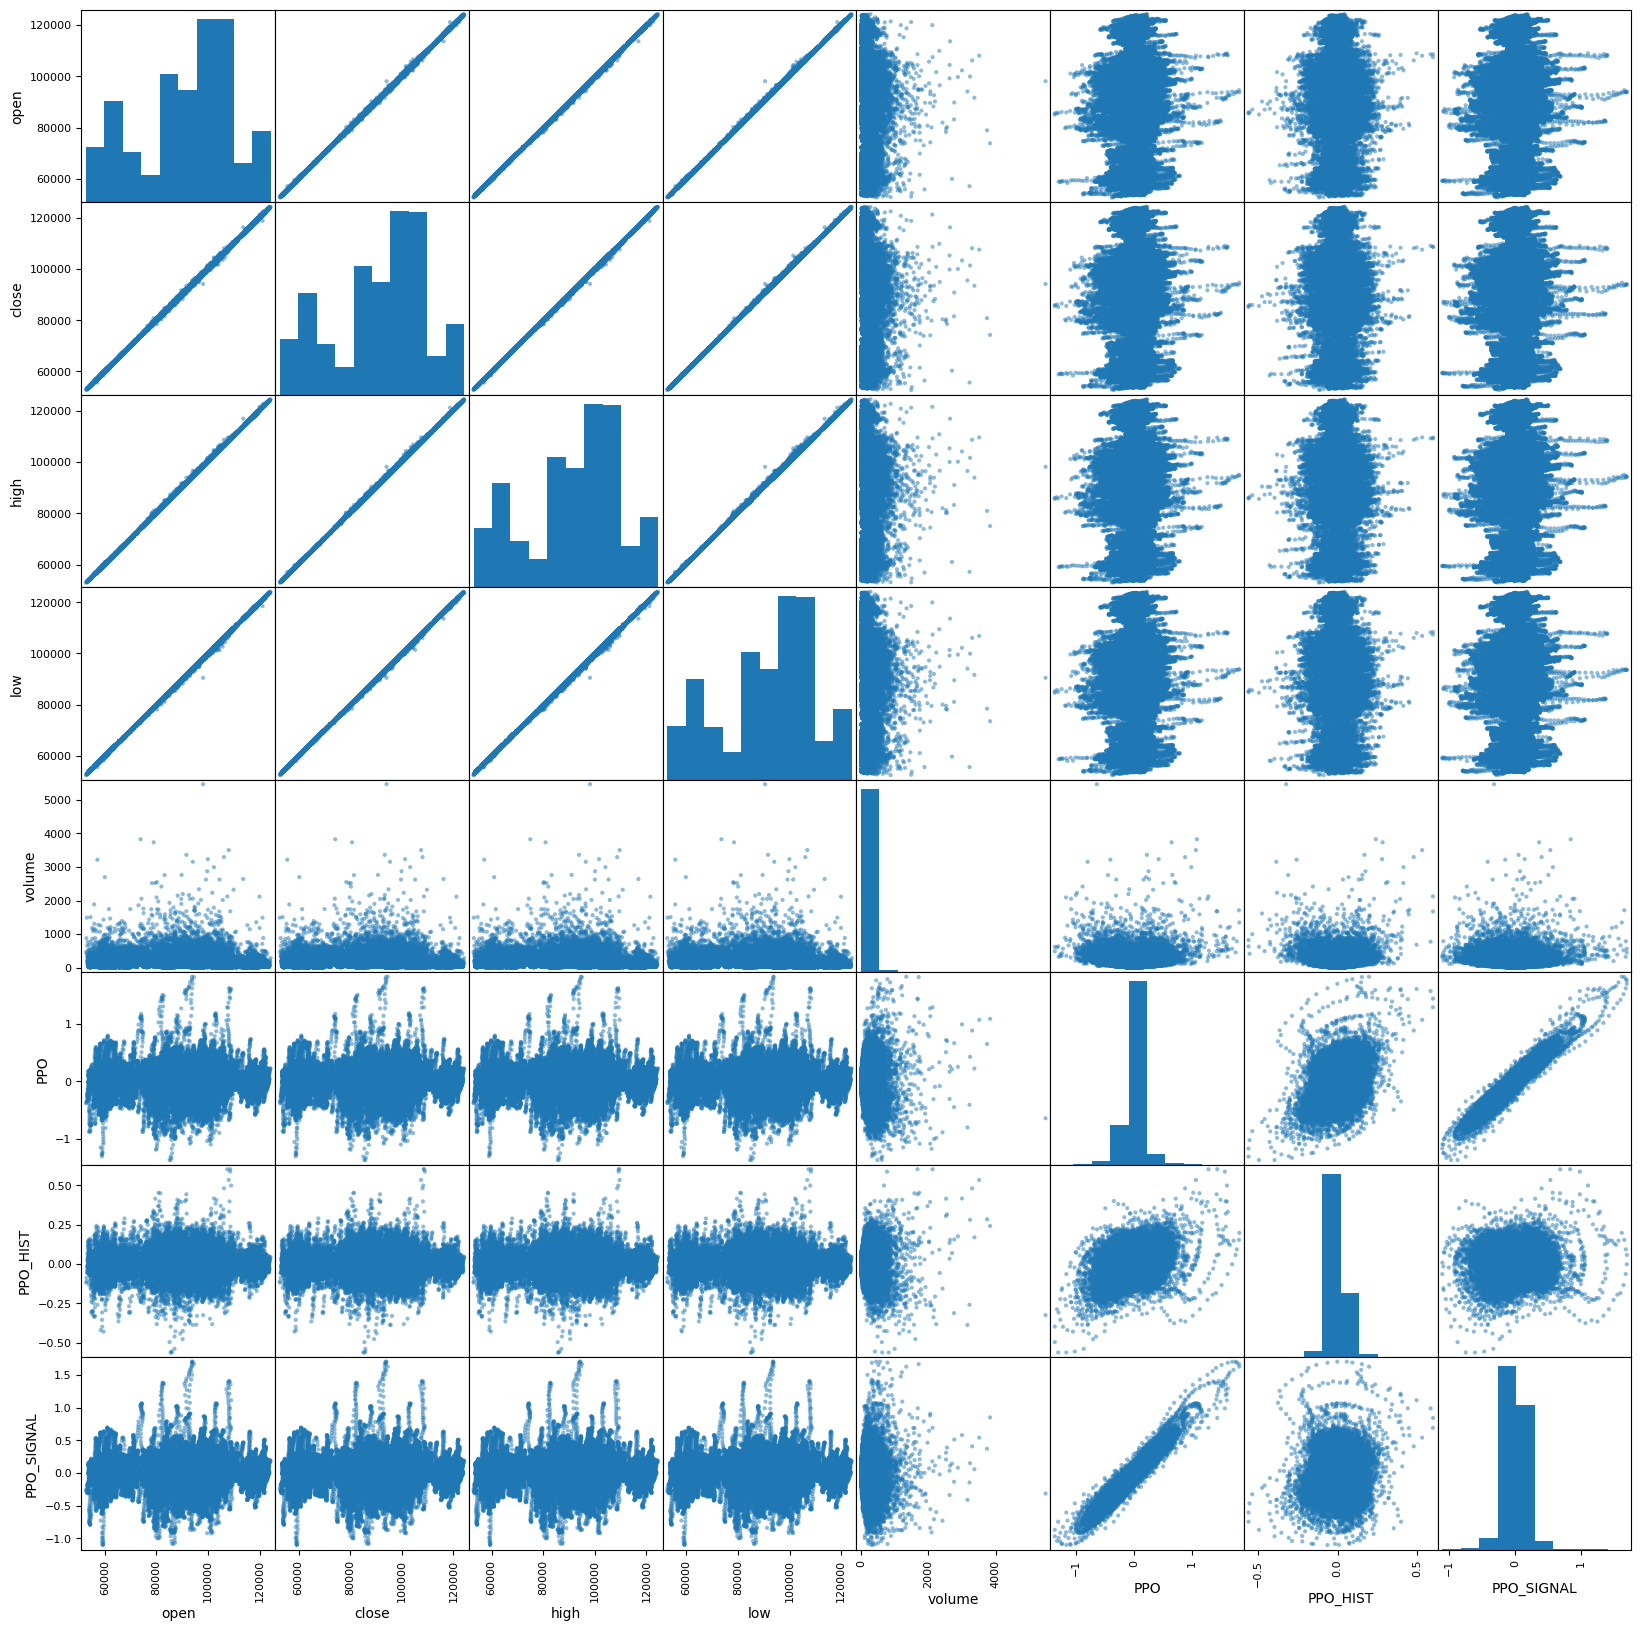

In [61]:
scatter_matrix(velas[OCHLV+MOMENTUM_PPO], figsize=(20, 20))
plt.show()

##### PVO

In [62]:
velas[OCHLV+MOMENTUM_PVO].corr()

,open,close,high,low,volume,PVO,PVO_HIST,PVO_SIGNAL
open,1.000000,0.999973,0.999984,0.999983,-0.078092,0.005508,-0.000185,0.006557
close,0.999973,1.000000,0.999985,0.999984,-0.078044,0.005518,-0.000174,0.006562
high,0.999984,0.999985,1.000000,0.999970,-0.075108,0.006852,0.000825,0.007570
low,0.999983,0.999984,0.999970,1.000000,-0.081215,0.004127,-0.001205,0.005504
volume,-0.078092,-0.078044,-0.075108,-0.081215,1.000000,0.456998,0.364466,0.331967
PVO,0.005508,0.005518,0.006852,0.004127,0.456998,1.000000,0.557691,0.869237
PVO_HIST,-0.000185,-0.000174,0.000825,-0.001205,0.364466,0.557691,1.000000,0.074394
PVO_SIGNAL,0.006557,0.006562,0.007570,0.005504,0.331967,0.869237,0.074394,1.000000


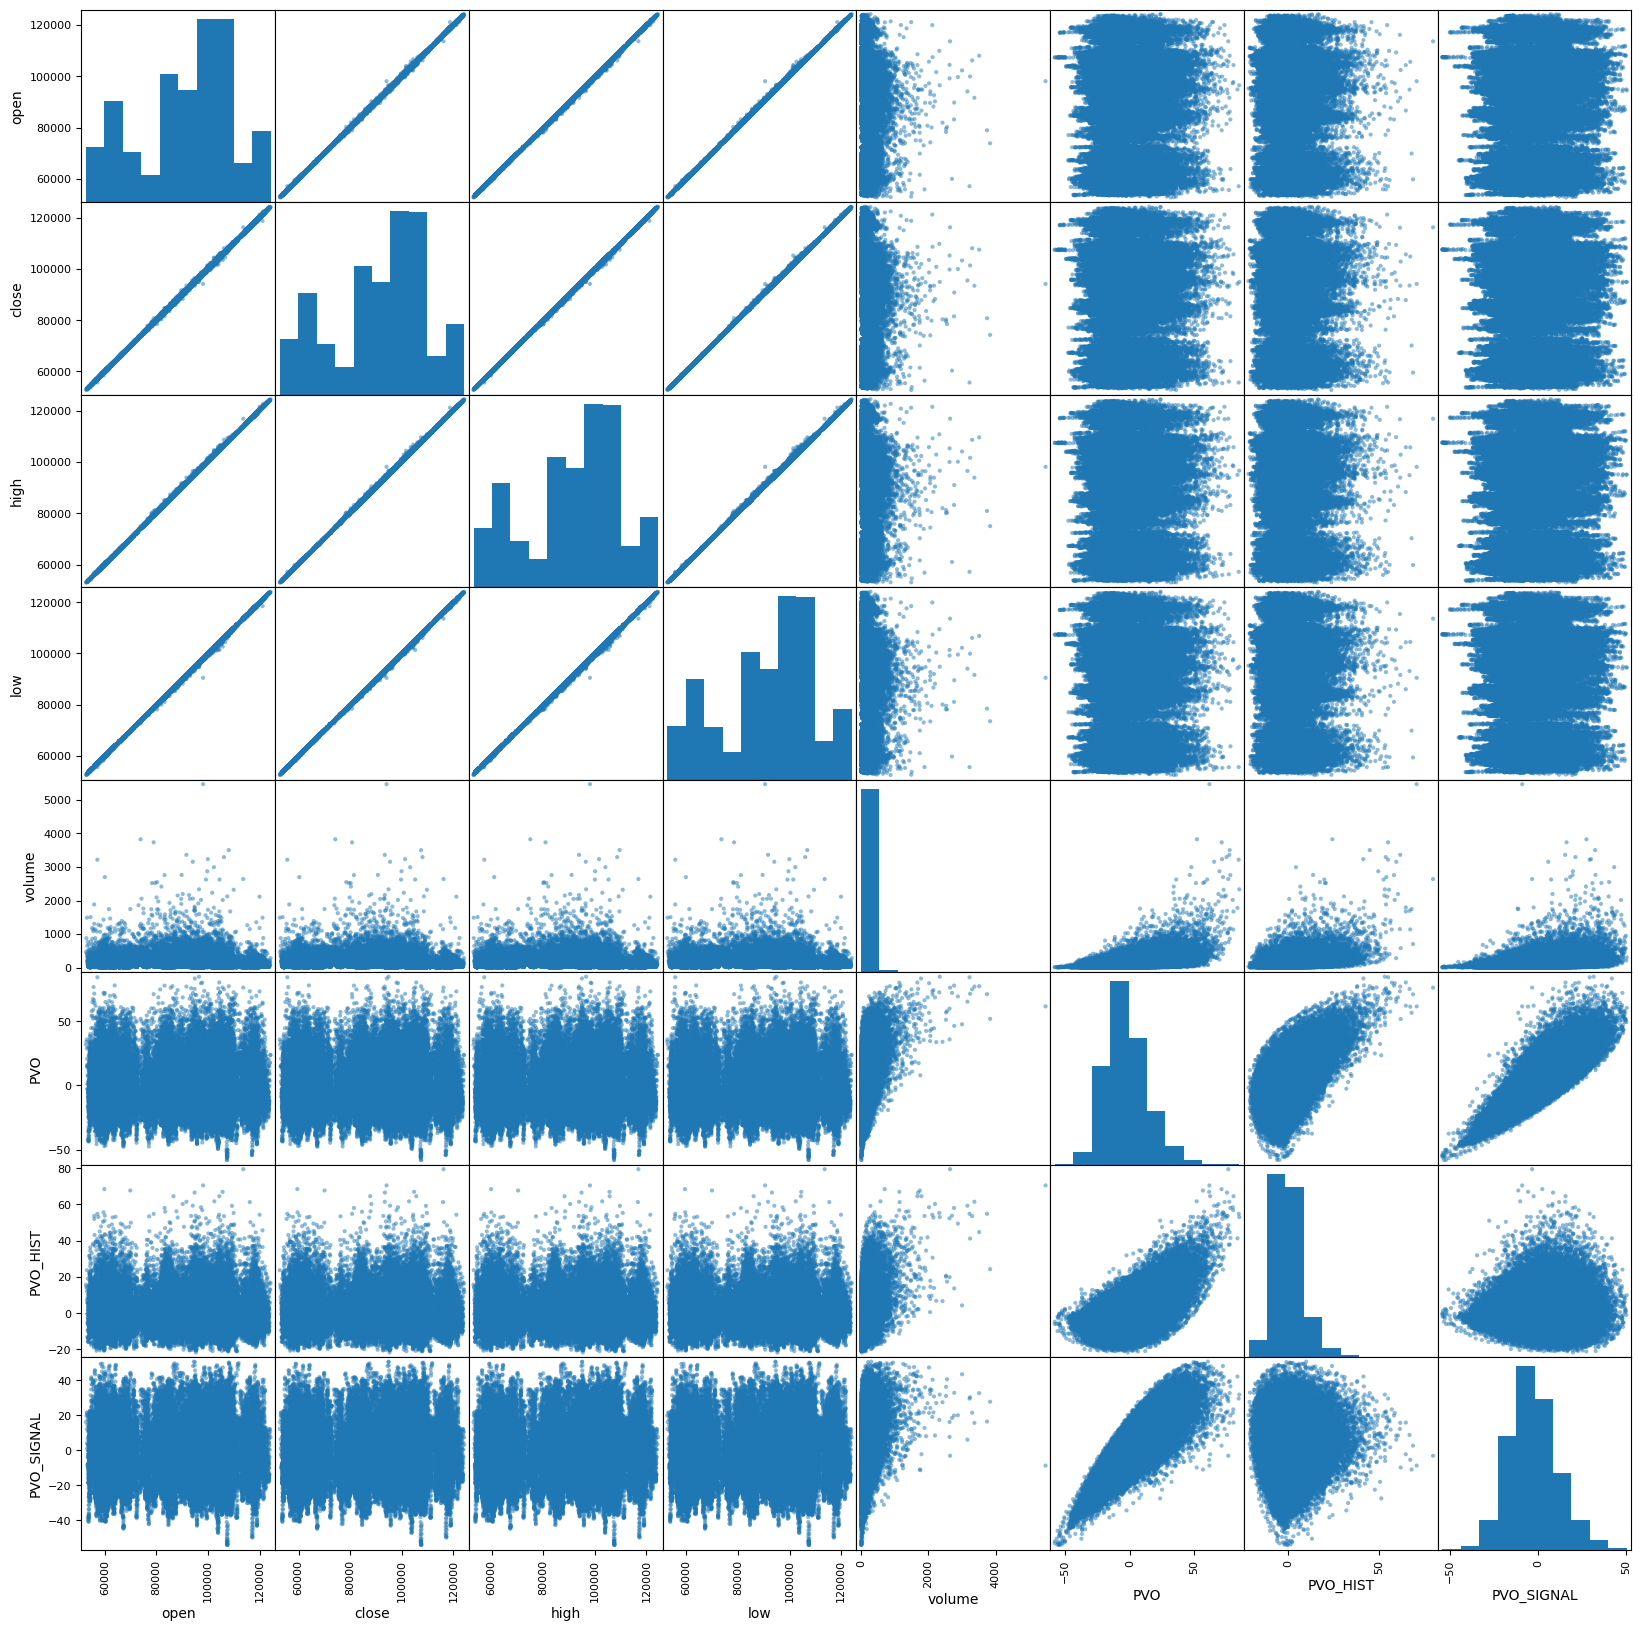

In [63]:
scatter_matrix(velas[OCHLV+MOMENTUM_PVO], figsize=(20, 20))
plt.show()

##### STOCH

In [64]:
velas[OCHLV+MOMENTUM_STOCH].corr()

,open,close,high,low,volume,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL
open,1.000000,0.999973,0.999984,0.999983,-0.078092,-0.001412,0.006314,0.008856
close,0.999973,1.000000,0.999985,0.999984,-0.078044,0.001702,0.009129,0.009834
high,0.999984,0.999985,1.000000,0.999970,-0.075108,0.000216,0.007613,0.009236
low,0.999983,0.999984,0.999970,1.000000,-0.081215,0.000237,0.007846,0.009511
volume,-0.078092,-0.078044,-0.075108,-0.081215,1.000000,0.001797,-0.006661,-0.008118
STOCH_RSI,-0.001412,0.001702,0.000216,0.000237,0.001797,1.000000,0.815148,0.660652
STOCH_OSC,0.006314,0.009129,0.007613,0.007846,-0.006661,0.815148,1.000000,0.909914
STOCH_OSC_SIGNAL,0.008856,0.009834,0.009236,0.009511,-0.008118,0.660652,0.909914,1.000000


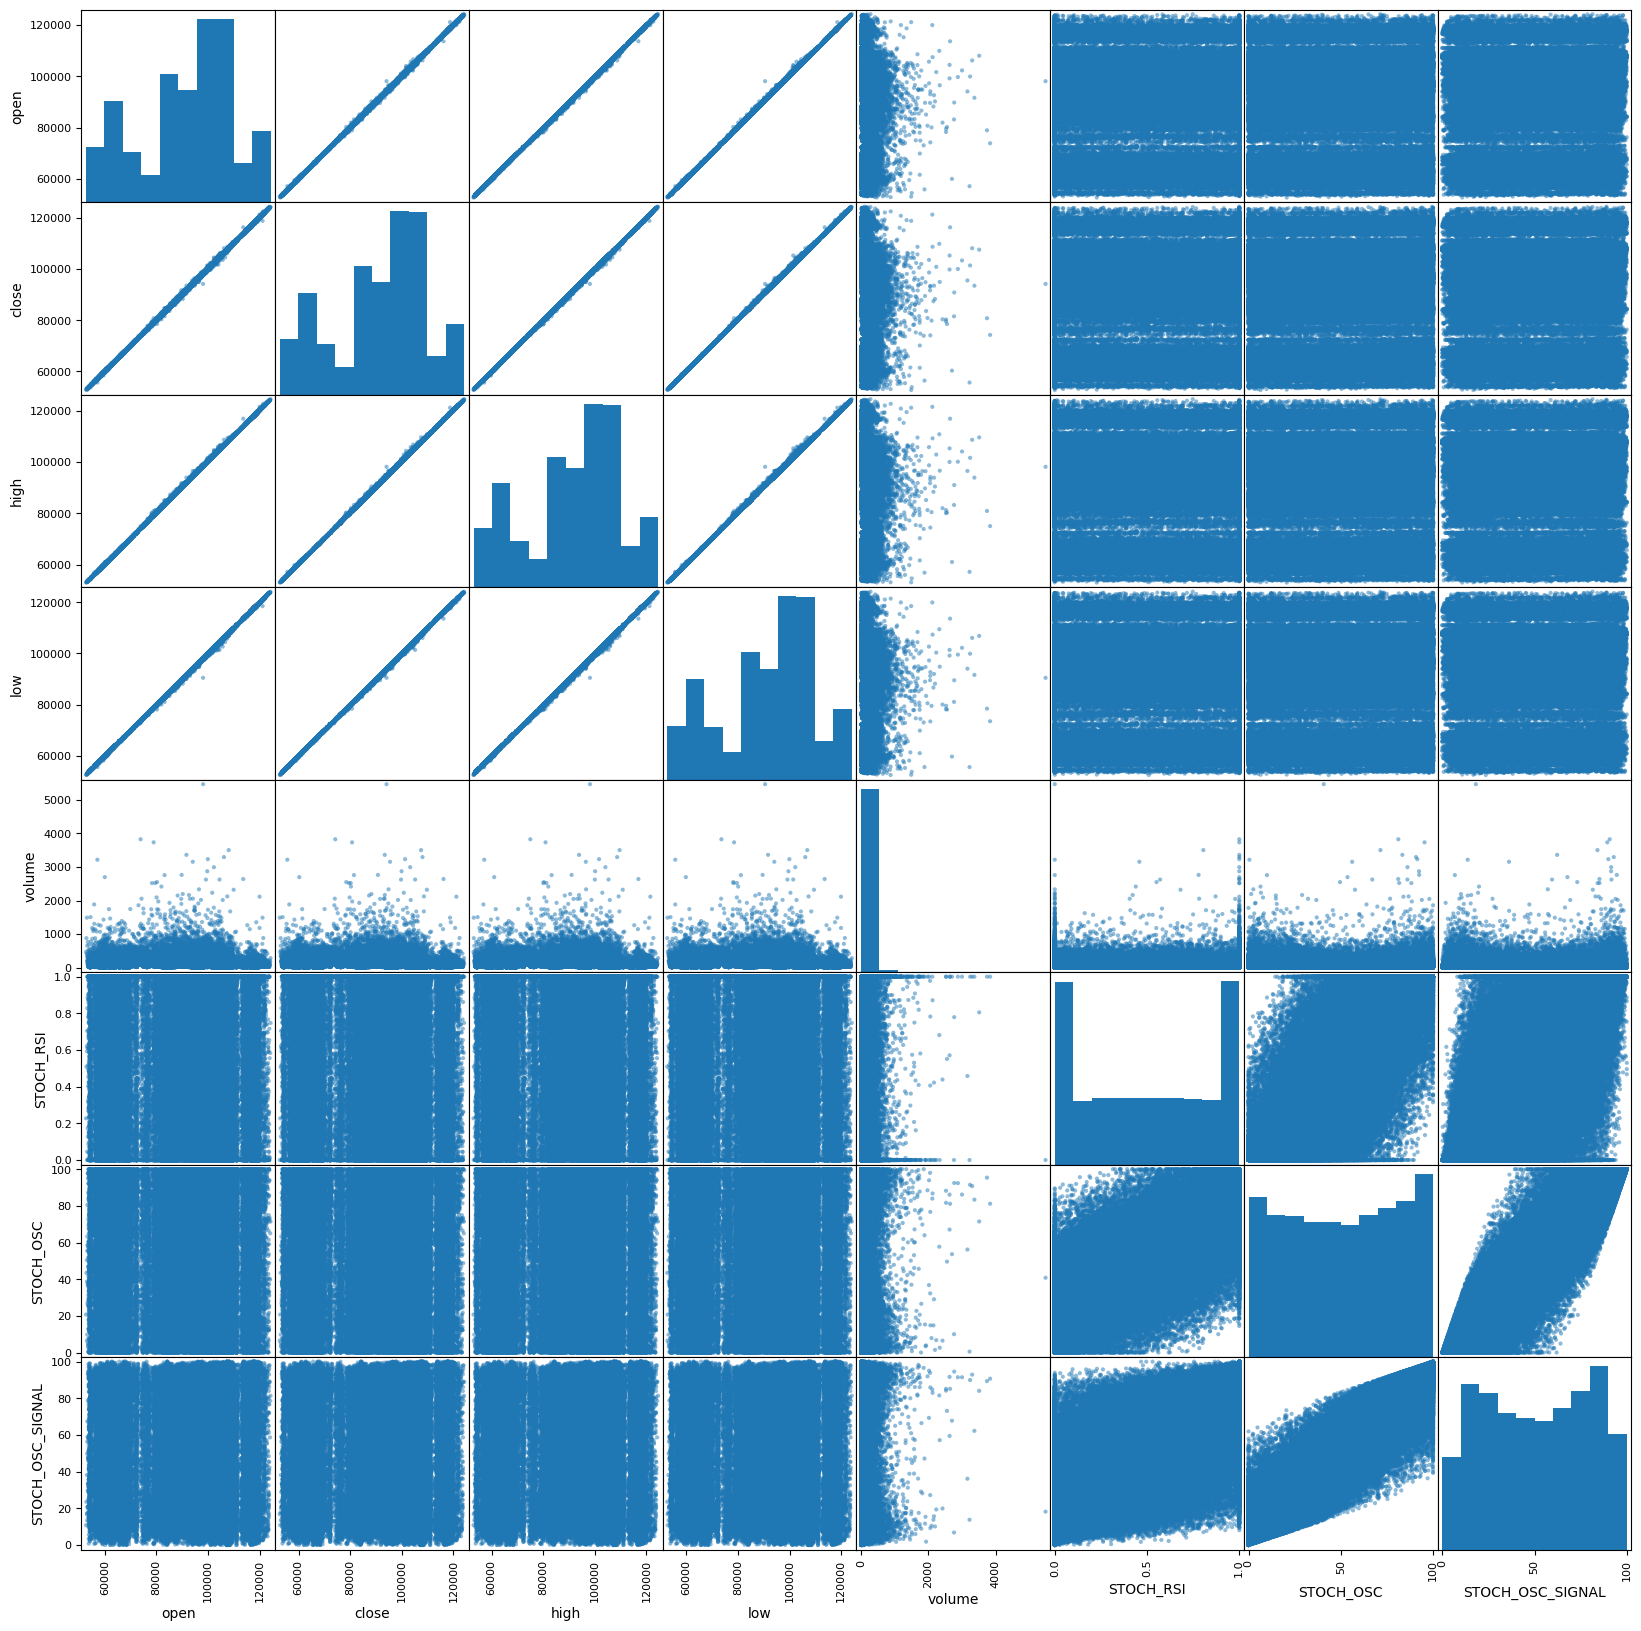

In [65]:
scatter_matrix(velas[OCHLV+MOMENTUM_STOCH], figsize=(20, 20))
plt.show()

##### Only MOMENTUM

In [66]:
velas[MOMENTUM].corr()

,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI
AO,1.000000,0.006682,0.958533,0.446455,0.875273,-0.053461,-0.015636,-0.054916,0.730978,0.707072,0.041808,0.411310,0.513151,0.834740
KAMA,0.006682,1.000000,0.003885,-0.007768,0.006543,0.006065,0.000107,0.007051,-0.003413,0.002171,-0.005321,0.000193,0.001539,0.007370
PPO,0.958533,0.003885,1.000000,0.337775,0.953936,-0.046508,-0.007929,-0.051189,0.702158,0.719558,0.017872,0.394367,0.476058,0.856657
PPO_HIST,0.446455,-0.007768,0.337775,1.000000,0.039836,-0.032744,-0.041041,-0.014894,0.824103,0.559604,0.574692,0.627767,0.675345,0.312739
PPO_SIGNAL,0.875273,0.006543,0.953936,0.039836,1.000000,-0.038968,0.004664,-0.049595,0.482749,0.585513,-0.164191,0.218597,0.290163,0.809745
PVO,-0.053461,0.006065,-0.046508,-0.032744,-0.038968,1.000000,0.557691,0.869237,-0.037464,-0.030311,-0.005850,-0.030002,-0.035978,-0.034433
PVO_HIST,-0.015636,0.000107,-0.007929,-0.041041,0.004664,0.557691,1.000000,0.074394,-0.029692,-0.009115,-0.012491,-0.021507,-0.024239,-0.003785
PVO_SIGNAL,-0.054916,0.007051,-0.051189,-0.014894,-0.049595,0.869237,0.074394,1.000000,-0.027298,-0.031002,0.000464,-0.023169,-0.028712,-0.039113
ROC,0.730978,-0.003413,0.702158,0.824103,0.482749,-0.037464,-0.029692,-0.027298,1.000000,0.746357,0.458850,0.662752,0.690270,0.616869
RSI,0.707072,0.002171,0.719558,0.559604,0.585513,-0.030311,-0.009115,-0.031002,0.746357,1.000000,0.516348,0.809101,0.803103,0.855293


# Training the model

In [67]:
dataset = df.copy()

In [68]:
dataset.head()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
0,2024-08-18 23:35:00,59009.99,59084.26,58879.03,58911.64,191.29887,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-08-18 23:40:00,58911.64,58928.21,58735.25,58804.00,218.17761,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-08-18 23:45:00,58804.00,58833.54,58582.09,58614.00,205.15583,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-08-18 23:50:00,58614.00,58658.00,58423.99,58527.52,317.89624,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-08-18 23:55:00,58527.53,58527.53,58408.92,58427.35,137.96323,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Cleaning

In [69]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105121 entries, 0 to 105120
Data columns (total 72 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   timestamp            105121 non-null  datetime64[ns]
 1   open                 105121 non-null  float64       
 2   high                 105121 non-null  float64       
 3   low                  105121 non-null  float64       
 4   close                105121 non-null  float64       
 5   volume               105121 non-null  float64       
 6   AO                   105088 non-null  float64       
 7   KAMA                 105112 non-null  float64       
 8   PPO                  105096 non-null  float64       
 9   PPO_HIST             105088 non-null  float64       
 10  PPO_SIGNAL           105088 non-null  float64       
 11  PVO                  105096 non-null  float64       
 12  PVO_HIST             105088 non-null  float64       
 13  PVO_SIGNAL    

###

In [70]:
dataset = DataCleaning(dataset).clean_data()

In [71]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 105081 entries, 40 to 105120
Data columns (total 72 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   timestamp            105081 non-null  datetime64[ns]
 1   open                 105081 non-null  float64       
 2   high                 105081 non-null  float64       
 3   low                  105081 non-null  float64       
 4   close                105081 non-null  float64       
 5   volume               105081 non-null  float64       
 6   AO                   105081 non-null  float64       
 7   KAMA                 105081 non-null  float64       
 8   PPO                  105081 non-null  float64       
 9   PPO_HIST             105081 non-null  float64       
 10  PPO_SIGNAL           105081 non-null  float64       
 11  PVO                  105081 non-null  float64       
 12  PVO_HIST             105081 non-null  float64       
 13  PVO_SIGNAL        

In [72]:
dataset.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
count,105081,105081.000000,105081.000000,105081.000000,105081.000000,105081.000000,105081.000000,105081.000000,105081.000000,105081.000000,...,105081.000000,105081.000000,105081.000000,105081.000000,105081.000000,105081.000000,105081.000000,105081.000000,105081.000000,105081.000000
mean,2025-02-17 13:15:00.000000256,91284.149866,91360.569702,91206.444505,91284.697410,62.751771,11.649499,91280.674321,0.006349,-0.000201,...,-0.006553,5.675822,5.629970,-0.143864,24.853331,91281.125206,1.007408,0.995765,0.011706,91282.318225
min,2024-08-19 02:55:00,52738.000000,53000.000000,52550.000000,52738.000000,0.909580,-609.662353,53352.968576,-0.267011,-0.085867,...,-3.109745,-239.653005,-225.750812,-76.438850,20.749662,53209.755714,0.502319,0.502202,-0.982891,53165.028000
25%,2024-11-18 08:05:00,81776.000000,81882.600000,81666.040000,81776.010000,27.814270,-113.265118,81785.980511,-0.048739,-0.018139,...,-0.657206,-43.448369,-40.812055,-15.946142,23.820065,81795.857857,0.882238,0.874939,-0.236982,81789.238667
50%,2025-02-17 13:15:00,95655.020000,95734.480000,95560.300000,95655.410000,51.411890,8.015288,95659.427126,0.004365,-0.000001,...,0.002643,3.864177,3.865403,-0.001226,24.752127,95663.427143,1.009805,0.998628,0.012168,95661.086571
75%,2025-05-19 18:25:00,104639.190000,104705.620000,104563.350000,104639.200000,88.529691,139.147441,104636.536298,0.062180,0.017506,...,0.635243,55.511291,52.765953,15.568115,25.759261,104636.790000,1.133273,1.120308,0.257159,104639.413048
max,2025-08-18 23:35:00,124243.310000,124474.000000,124124.990000,124243.320000,208.025290,631.676118,123679.668836,0.279555,0.085647,...,3.100008,250.812143,237.200561,76.499005,28.922377,123831.152143,1.512274,1.491083,1.003134,123844.266190
std,NaN,17895.965688,17902.418993,17888.925463,17895.848704,43.909535,218.050482,17898.178907,0.095939,0.030588,...,1.107910,86.088836,81.699518,27.346468,1.480075,17895.513383,0.175150,0.171474,0.343568,17895.449673


### Candlestick chart

In [73]:
import plotly.graph_objects as go
dataset = dataset.sort_values('timestamp')

# Create candlestick figure
fig = go.Figure(data=[
    go.Candlestick(
        x=dataset['timestamp'],
        open=dataset['open'],
        high=dataset['high'],
        low=dataset['low'],
        close=dataset['close'],
        name='OHLC'
    )
])

# Add layout options
fig.update_layout(
    title='Interactive Candlestick Chart',
    xaxis_title='Timestamp',
    yaxis_title='Price',
    xaxis_rangeslider_visible=False,
    template='plotly_dark',
    height=600
)

fig.write_html("candlestick_chart.html", auto_open=True)

### Line Chart fot the target labels

In [74]:


def plot_line_chart(dataset, timestamp, columns):
    for column in columns:
        sns.lineplot(x=timestamp, y=column, data=dataset)
        plt.gcf().autofmt_xdate()
        plt.show()


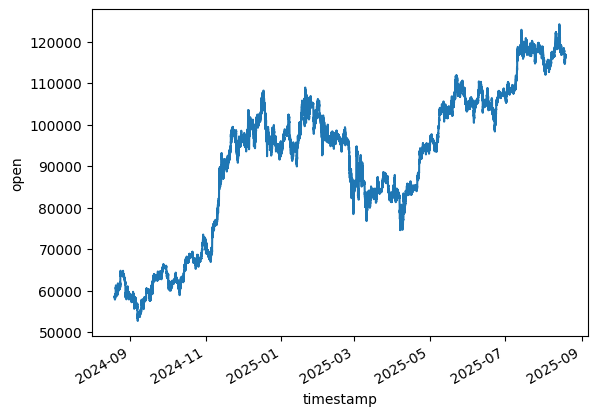

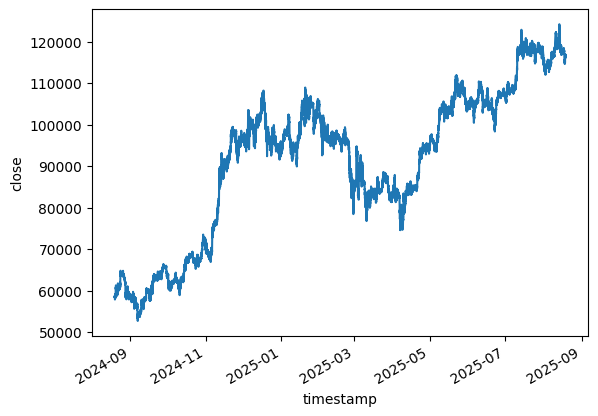

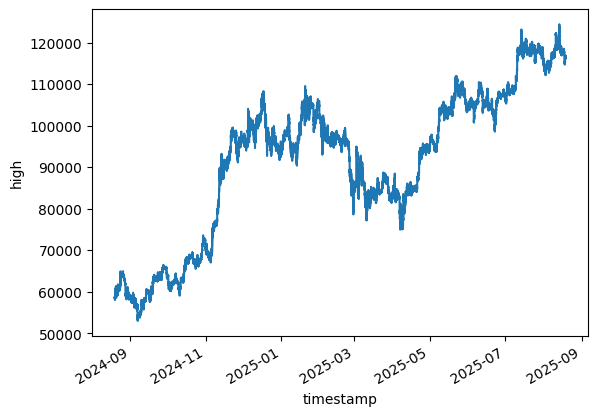

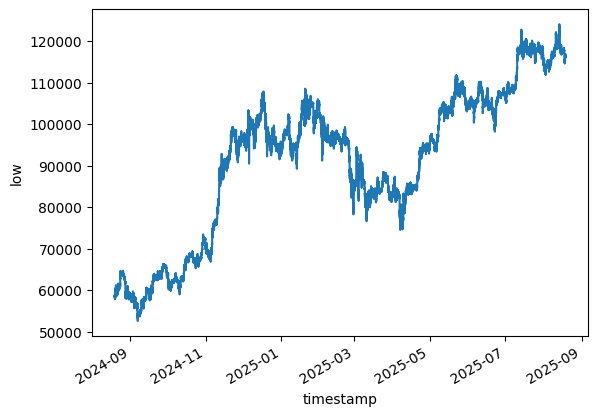

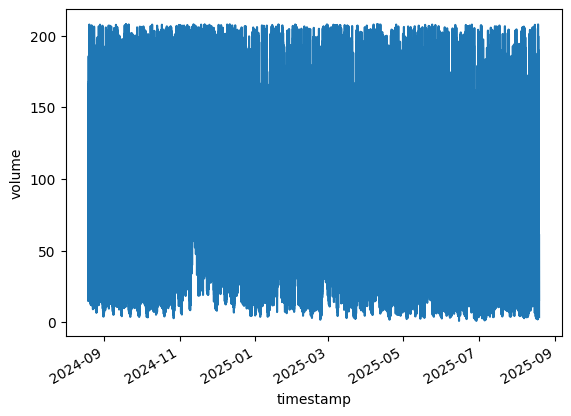

In [75]:
plot_line_chart(dataset, "timestamp", OCHLV)

# Feature Selection

### Spliting the dataset into training and test

In [219]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor

#### Creating exclusive time series features

In [205]:
dataset["hour"] = dataset['timestamp'].dt.hour
dataset['dayofweek'] = dataset['timestamp'].dt.dayofweek
dataset['quarter'] = dataset['timestamp'].dt.quarter
dataset['month'] = dataset['timestamp'].dt.month
dataset['year'] = dataset['timestamp'].dt.year
dataset['dayofyear'] = dataset['timestamp'].dt.dayofyear
dataset['dayofmonth'] = dataset['timestamp'].dt.day

In [207]:
dataset.head()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,VI_NEG,VI_DIFF,WMA,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth
40,2024-08-19 02:55:00,58706.54,58721.53,58670.50,58670.51,37.11141,127.753324,58476.634877,0.041411,0.033643,...,0.909216,0.196915,58615.873524,2,0,3,8,2024,232,19
41,2024-08-19 03:00:00,58670.51,58728.39,58637.99,58728.39,43.26430,123.234971,58501.276656,0.054437,0.037335,...,0.862626,0.310635,58635.221333,3,0,3,8,2024,232,19
42,2024-08-19 03:05:00,58728.39,58734.38,58664.25,58709.47,28.62284,140.219000,58515.985563,0.061444,0.035474,...,0.868436,0.329461,58649.196571,3,0,3,8,2024,232,19
43,2024-08-19 03:10:00,58709.46,58712.63,58571.84,58594.20,63.79792,143.268118,58516.606231,0.050549,0.019663,...,0.883425,0.164874,58646.417048,3,0,3,8,2024,232,19
44,2024-08-19 03:15:00,58597.57,58645.99,58565.00,58594.42,36.26699,127.594265,58517.057931,0.041468,0.008465,...,0.963877,0.073448,58643.060190,3,0,3,8,2024,232,19


In [230]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 105081 entries, 40 to 105120
Data columns (total 79 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   timestamp            105081 non-null  datetime64[ns]
 1   open                 105081 non-null  float64       
 2   high                 105081 non-null  float64       
 3   low                  105081 non-null  float64       
 4   close                105081 non-null  float64       
 5   volume               105081 non-null  float64       
 6   AO                   105081 non-null  float64       
 7   KAMA                 105081 non-null  float64       
 8   PPO                  105081 non-null  float64       
 9   PPO_HIST             105081 non-null  float64       
 10  PPO_SIGNAL           105081 non-null  float64       
 11  PVO                  105081 non-null  float64       
 12  PVO_HIST             105081 non-null  float64       
 13  PVO_SIGNAL        

#### Creating train and test dataset

In [231]:
dataset = dataset.sort_values('timestamp')

In [232]:
cutoff_date = dataset['timestamp'].quantile(0.8)
open_train = dataset[dataset['timestamp'] < cutoff_date]
open_test = dataset[dataset['timestamp'] >= cutoff_date]

In [233]:
X_open_train = open_train.drop(columns=['open', 'timestamp'])
y_open_train = open_train['open']
X_open_test = open_test.drop(columns=['open', 'timestamp'])
y_open_test = open_test['open']

#### Ploting train and test dataset

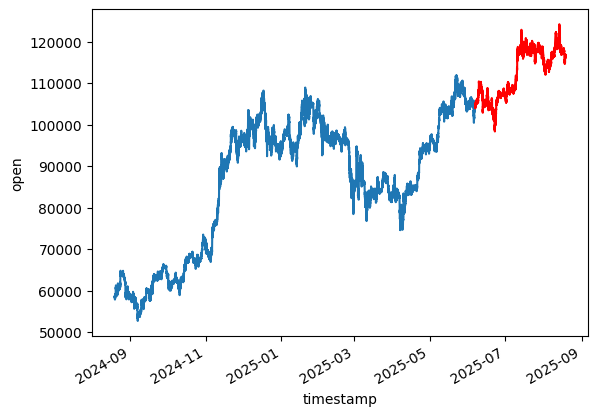

In [234]:
#### Ploting train dataset
sns.lineplot(x="timestamp", y="open", data=open_train)
sns.lineplot(x="timestamp", y="open", data=open_test, color="red")
plt.gcf().autofmt_xdate()
plt.show()

### Hyperparameter tuning

In [235]:
params = {
        "n_estimators": [200, 500, 800, 1000, 2000, 5000],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [3, 5, 7, 10, 15],
        "min_child_weight": [1, 3, 5, 10],
        "gamma": [0, 0.5, 1, 1.5, 2],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "reg_lambda": [0, 1, 5, 10],
        "reg_alpha": [0, 0.5, 1, 5]
}

In [236]:
xgb_open = XGBRegressor(objective='reg:squarederror')
xgb_open

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [237]:
tscv = TimeSeriesSplit(n_splits=10)

In [238]:
random_search_open = RandomizedSearchCV(xgb_open, param_distributions=params, n_iter=10, scoring='neg_root_mean_squared_error', cv=tscv, verbose=3)

In [239]:
random_search_open.fit(X_open_train, y_open_train)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
[CV 1/10] END colsample_bytree=0.8, gamma=2, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=200, reg_alpha=1, reg_lambda=0, subsample=1.0;, score=-433.709 total time=   0.6s
[CV 2/10] END colsample_bytree=0.8, gamma=2, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=200, reg_alpha=1, reg_lambda=0, subsample=1.0;, score=-2874.837 total time=   0.6s
[CV 3/10] END colsample_bytree=0.8, gamma=2, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=200, reg_alpha=1, reg_lambda=0, subsample=1.0;, score=-17695.898 total time=   0.6s
[CV 4/10] END colsample_bytree=0.8, gamma=2, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=200, reg_alpha=1, reg_lambda=0, subsample=1.0;, score=-2517.796 total time=   0.7s
[CV 5/10] END colsample_bytree=0.8, gamma=2, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=200, reg_alpha=1, reg_lambda=0, subsample=1.0;, sc

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=10, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gam...
                                          num_parallel_tree=None, ...),
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.5, 1, 1.5, 2],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7, 10, 15],
                                        'min_child_weight': [1, 3, 5, 10],
                                        'n_estimators': [200, 500, 800, 1000,
                                                         2000, 5000],
                                        'reg_alpha': [0, 0.5, 1, 5],
                                        'reg_lambda': [0, 1, 5, 10],
                                        'subsample': [0.6, 0.8, 1.0]},
                   scoring='neg_root_mean_squared_error', verbose=3)

In [240]:

print('\n Best hyperparameters:')
print(random_search_open.best_params_)
results = pd.DataFrame(random_search_open.cv_results_)
results


 Best hyperparameters:
{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.8}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_reg_lambda,param_reg_alpha,param_n_estimators,param_min_child_weight,param_max_depth,...,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,1.060776,0.354747,0.009882,0.002166,1.0,0,1.0,200,1,5,...,-2517.796343,-3595.924910,-123.325894,-2804.429878,-226.595294,-56.824402,-1012.717913,-3134.205878,5015.927634,7
1,8.273025,1.512087,0.081512,0.138164,0.8,0,0.5,1000,10,7,...,-2521.864662,-7919.534232,-58.022909,-2842.963470,-207.475118,-48.183687,-1053.880195,-3571.074244,5238.022667,10
2,2.220259,0.416776,0.013479,0.003618,0.8,10,1.0,200,1,7,...,-2592.420838,-3932.598631,-139.857201,-2577.721795,-197.948867,-86.198359,-1083.761304,-3180.818665,5056.217204,9
3,0.983132,0.291691,0.012200,0.004369,1.0,5,5.0,200,5,5,...,-2529.565216,-2470.640880,-71.783154,-2814.125967,-217.134471,-57.746522,-1029.221346,-3026.407883,5038.801540,3
4,28.130119,13.993524,0.118502,0.052761,1.0,5,5.0,5000,5,7,...,-2529.981807,-2143.742902,-69.595729,-2665.287874,-224.063068,-50.640936,-1054.806326,-2982.544408,5047.665382,2
5,30.546247,15.456363,0.114779,0.050059,1.0,1,0.5,5000,3,7,...,-2534.691893,-3381.066879,-63.971763,-2671.524210,-204.214644,-50.501237,-1032.435901,-3098.017015,5038.457402,6
6,2.259386,0.477730,0.017154,0.003723,1.0,5,0.0,500,1,5,...,-2524.308972,-2339.467990,-102.201864,-2976.093392,-225.205429,-59.889800,-1029.113795,-3033.490391,5036.706769,4
7,1.560673,0.716247,0.012691,0.002407,0.8,5,0.0,500,3,3,...,-2770.701547,-1640.296330,-162.400290,-1877.350577,-216.970532,-104.574593,-1374.639406,-2953.852899,5093.613902,1
8,111.734952,54.986782,0.262532,0.077736,0.6,10,0.0,5000,5,10,...,-2544.080783,-3080.374666,-66.467716,-2511.040785,-200.217459,-51.064788,-1089.056677,-3065.093613,5046.850432,5
9,25.668493,9.447568,0.047579,0.007338,0.8,1,1.0,500,10,15,...,-2521.380379,-4352.992336,-61.468431,-2523.166373,-203.870735,-49.989524,-1065.142564,-3180.311361,5046.939871,8


### Feature importance and Feature selection

In [241]:
params=random_search_open.best_params_

In [242]:
xgb_open = XGBRegressor(objective='reg:squarederror', **params)

In [243]:
xgb_open.fit(X_open_train, y_open_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.5, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

Extract feature importance

In [244]:
importance_open = xgb_open.feature_importances_
feature_names_open = X_open_train.columns
feature_importance_open = pd.DataFrame({'Feature': feature_names_open, 'Importance': importance_open})
feature_importance_open.sort_values(by='Importance', ascending=False, inplace=True)
print(feature_importance_open)

          Feature  Importance
33  BBANDS_MIDDLE    0.407398
43    KELTNER_LOW    0.150076
2           close    0.118175
0            high    0.095924
1             low    0.075386
..            ...         ...
72        quarter    0.000000
73          month    0.000000
74           year    0.000000
75      dayofyear    0.000000
76     dayofmonth    0.000000

[77 rows x 2 columns]


Plot feature importance

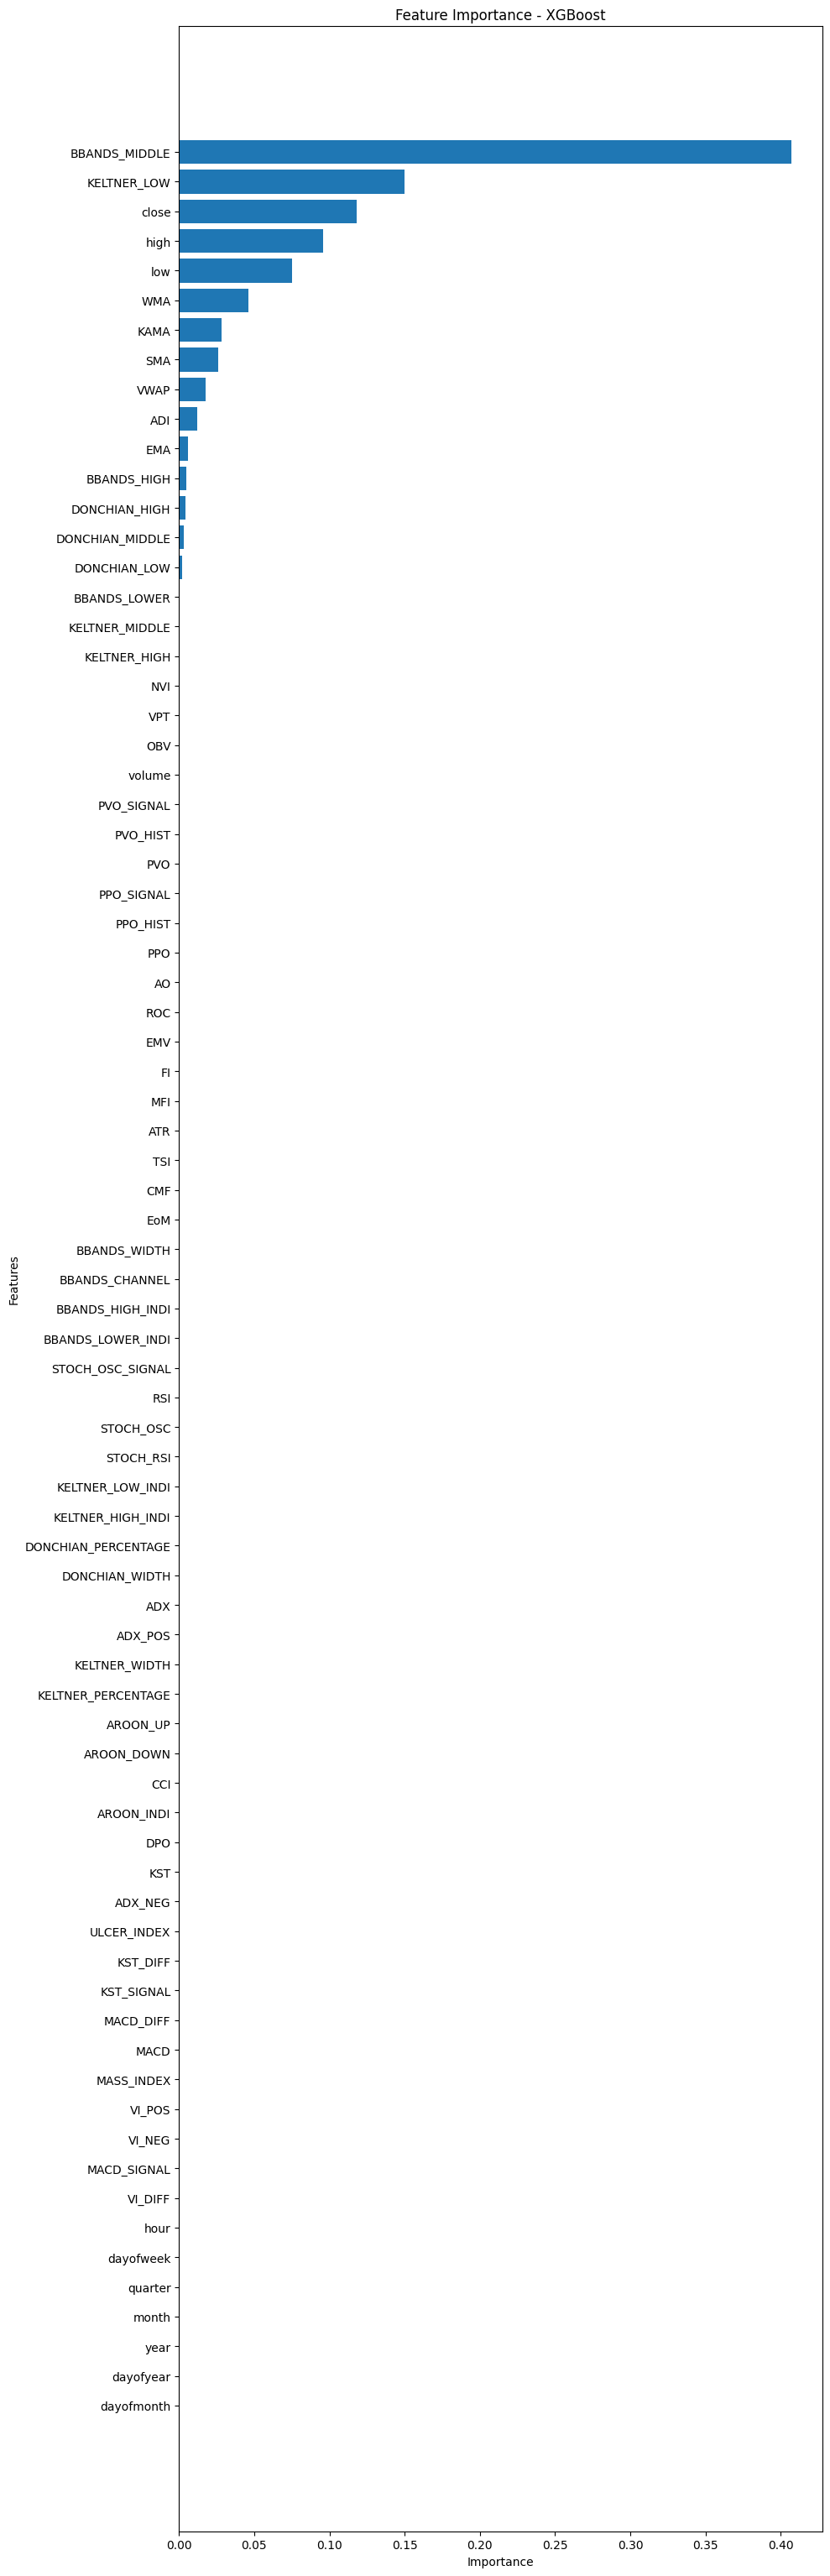

In [245]:
features = feature_importance_open['Feature']
importance = feature_importance_open['Importance']

plt.figure(figsize=(10, 0.4 * len(features)))

plt.barh(features, importance)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance - XGBoost")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Feature selection - Select top features until 90% contribution

In [246]:
feature_importance_open.head(10)

,Feature,Importance
33,BBANDS_MIDDLE,0.407398
43,KELTNER_LOW,0.150076
2,close,0.118175
0,high,0.095924
1,low,0.075386
69,WMA,0.046154
5,KAMA,0.028053
65,SMA,0.025882
27,VWAP,0.017957
18,ADI,0.012002


In [247]:
selected_features = feature_importance_open[feature_importance_open['Importance'] > 0.01]['Feature'].tolist()

In [248]:
selected_features

['BBANDS_MIDDLE',
 'KELTNER_LOW',
 'close',
 'high',
 'low',
 'WMA',
 'KAMA',
 'SMA',
 'VWAP',
 'ADI']

### Creating train and test dataset only with the selected features

In [250]:
X_open_train = open_train[selected_features]
y_open_train = open_train['open']
X_open_test = open_test[selected_features]
y_open_test = open_test['open']

In [251]:
X_open_train.head()

,BBANDS_MIDDLE,KELTNER_LOW,close,high,low,WMA,KAMA,SMA,VWAP,ADI
40,58566.8625,58462.587833,58670.51,58721.53,58670.50,58615.873524,58476.634877,58583.281429,58568.736017,120806.019856
41,58584.2105,58480.941500,58728.39,58728.39,58637.99,58635.221333,58501.276656,58604.655714,58606.634949,120806.019856
42,58597.2615,58497.607833,58709.47,58734.38,58664.25,58649.196571,58515.985563,58615.046429,58616.970464,120806.019856
43,58598.4885,58502.970167,58594.20,58712.63,58571.84,58646.417048,58516.606231,58619.596429,58624.626553,120806.019856
44,58597.4600,58504.479667,58594.42,58645.99,58565.00,58643.060190,58517.057931,58621.767857,58625.958194,120806.019856


### Hyperparameter tuning witht the selected features

In [ ]:
params = {
        "n_estimators": [200, 500, 800, 1000, 2000, 5000],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [3, 5, 7, 10, 15],
        "min_child_weight": [1, 3, 5, 10],
        "gamma": [0, 0.5, 1, 1.5, 2],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "reg_lambda": [0, 1, 5, 10],
        "reg_alpha": [0, 0.5, 1, 5]
}

In [167]:
xgb_open = XGBRegressor(learning_rate=0.05, objective='reg:squarederror', n_estimators=1000)
xgb_open

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [168]:
random_search_open = RandomizedSearchCV(xgb_open, param_distributions=params, n_iter=10, scoring='neg_mean_squared_error', cv=None, verbose=3)

In [169]:
random_search_open.fit(X_open_train, y_open_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END colsample_bytree=0.6, gamma=1, max_depth=3, min_child_weight=10, subsample=0.8;, score=-38166966.191 total time=   1.0s
[CV 2/5] END colsample_bytree=0.6, gamma=1, max_depth=3, min_child_weight=10, subsample=0.8;, score=-2681103.859 total time=   1.0s
[CV 3/5] END colsample_bytree=0.6, gamma=1, max_depth=3, min_child_weight=10, subsample=0.8;, score=-14792.801 total time=   1.3s
[CV 4/5] END colsample_bytree=0.6, gamma=1, max_depth=3, min_child_weight=10, subsample=0.8;, score=-60744.521 total time=   1.0s
[CV 5/5] END colsample_bytree=0.6, gamma=1, max_depth=3, min_child_weight=10, subsample=0.8;, score=-505557.396 total time=   1.1s
[CV 1/5] END colsample_bytree=0.8, gamma=2, max_depth=10, min_child_weight=10, subsample=1.0;, score=-38138961.665 total time=   1.7s
[CV 2/5] END colsample_bytree=0.8, gamma=2, max_depth=10, min_child_weight=10, subsample=1.0;, score=-2681807.907 total time=   1.2s
[CV 3/5] END col

RandomizedSearchCV(estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=Non...
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=1000, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0.5, 1, 1.5, 2, 5],
                                        'max_depth': [3, 4, 5, 10],
                                        'min_child_weight': [1, 5, 10],
                                        'subsample': [0.6, 0.8, 1.0]},
                   scoring='neg_mean_squared_error', verbose=3)

In [170]:
print('\n Best hyperparameters:')
print(random_search_open.best_params_)
results = pd.DataFrame(random_search_open.cv_results_)
results


 Best hyperparameters:
{'subsample': 0.8, 'min_child_weight': 5, 'max_depth': 10, 'gamma': 2, 'colsample_bytree': 0.8}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_min_child_weight,param_max_depth,param_gamma,param_colsample_bytree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.131714,0.095681,0.036598,0.027234,0.8,10,3,1.0,0.6,"{'subsample': 0.8, 'min_child_weight': 10, 'ma...",-3.816697e+07,-2.681104e+06,-14792.801353,-60744.521413,-505557.396096,-8.285833e+06,1.497257e+07,8
1,1.379713,0.159068,0.119654,0.038089,1.0,10,10,2.0,0.8,"{'subsample': 1.0, 'min_child_weight': 10, 'ma...",-3.813896e+07,-2.681808e+06,-10785.514818,-54772.397855,-501729.821167,-8.277611e+06,1.496284e+07,4
2,1.251091,0.102511,0.044614,0.011068,0.6,1,4,0.5,1.0,"{'subsample': 0.6, 'min_child_weight': 1, 'max...",-3.815169e+07,-2.682375e+06,-12090.283974,-56297.144286,-499013.613664,-8.280292e+06,1.496785e+07,5
3,1.249849,0.056447,0.053449,0.022695,0.6,1,4,1.5,0.6,"{'subsample': 0.6, 'min_child_weight': 1, 'max...",-3.815531e+07,-2.675965e+06,-13309.985039,-57284.927758,-500173.655813,-8.280409e+06,1.496941e+07,7
4,2.168876,0.087672,0.084370,0.015168,0.8,5,10,2.0,0.8,"{'subsample': 0.8, 'min_child_weight': 5, 'max...",-3.810515e+07,-2.676933e+06,-10547.967354,-53885.133437,-500767.686305,-8.269457e+06,1.494994e+07,1
5,2.693792,0.069860,0.089685,0.008135,0.6,1,10,2.0,1.0,"{'subsample': 0.6, 'min_child_weight': 1, 'max...",-3.813828e+07,-2.680668e+06,-10582.105286,-53537.204911,-498837.314672,-8.276381e+06,1.496311e+07,3
6,1.113154,0.061841,0.022353,0.001952,0.8,5,3,0.5,0.6,"{'subsample': 0.8, 'min_child_weight': 5, 'max...",-3.814259e+07,-2.680422e+06,-14768.388014,-59993.043829,-504014.636761,-8.280358e+06,1.496314e+07,6
7,1.345758,0.082268,0.050073,0.006632,0.8,5,5,1.5,1.0,"{'subsample': 0.8, 'min_child_weight': 5, 'max...",-3.811814e+07,-2.670166e+06,-11444.777971,-55387.676857,-501423.475893,-8.271312e+06,1.495529e+07,2
8,1.213401,0.088386,0.024050,0.001444,0.6,10,3,2.0,0.8,"{'subsample': 0.6, 'min_child_weight': 10, 'ma...",-3.818232e+07,-2.690901e+06,-14570.058051,-59219.002158,-503556.187525,-8.290113e+06,1.497837e+07,9
9,0.464671,0.050787,0.023657,0.002254,1.0,5,3,1.0,0.6,"{'subsample': 1.0, 'min_child_weight': 5, 'max...",-3.831631e+07,-2.669766e+06,-14263.771596,-59094.053481,-521576.147562,-8.316202e+06,1.503161e+07,10


In [ ]:
{
        "n_estimators": [200, 500, 800, 1000],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [3, 5, 7],
        "min_child_weight": [1, 3, 5, 10],
        "gamma": [0, 0.5, 1, 2],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "reg_lambda": [0, 1, 5, 10],
        "reg_alpha": [0, 0.5, 1, 5]
}